# Regresie — Insurance Charges

Acest notebook rezolvă problema de **regresie** folosind setul de date `insurance.csv`.

**Pașii proiectului:**
1. Exploratory Data Analysis (EDA)
2. Preprocesare și Data Splitting
3. Evaluarea modelelor Baseline
4. Hyperparameter tuning (selectăm doar Top 5 modele)
5. Learning Curves & interpretare cu SHAP (doar pe top 5)


In [2]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.ml_utils import (
    load_dataset,
    split_data,
    save_eda_plots,
    train_baseline_models,
    tune_all_models,
    save_learning_curves,
    save_shap_plots_all_models,
    save_artifacts,
    rank_results,
)

DATA_PATH = ROOT / "data" / "insurance.csv"
OUTPUT_ROOT = ROOT / "outputs"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 1. Definirea problemei


Problema de regresie constă în estimarea costurilor medicale de asigurare pentru o persoană. Se urmărește construirea unui model care primește caracteristici demografice și medicale, iar la ieșire produce o valoare numerică estimată pentru costul asigurării.


Variabila țintă este `charges`. Variabilele de intrare sunt toate celelalte coloane din setul de date. Scopul modelelor este să învețe relația dintre aceste caracteristici și variabila țintă, astfel încât să poată produce predicții pentru observații noi.

Relevanța practică a problemei este dată de faptul că estimarea costurilor medicale de asigurare poate sprijini procesul de analiză și decizie. Modelul nu înlocuiește decizia umană, dar poate oferi o estimare rapidă și consecventă pe baza datelor disponibile.


### Variabila de ieșire pentru regresie

Variabila `charges` reprezintă costul medical individual facturat de asigurare. Este o valoare numerică continuă, exprimată în unități monetare. Deoarece modelul prezice o valoare numerică, problema este una de regresie.


In [3]:
df = load_dataset(DATA_PATH)
print(f"Dimensiune dataset: {df.shape}\n")

df.info()

print("\nStatistici pentru variabila target (charges):")
display(df["charges"].describe())

Dimensiune dataset: (1338, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Statistici pentru variabila target (charges):


count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

## 2. Analiza exploratorie a datelor

În această etapă verific structura datelor, tipurile de variabile, valorile lipsă, distribuția variabilei țintă, distribuția variabilelor numerice și relațiile dintre variabile. Scopul EDA este să înțeleg dacă datele sunt curate, echilibrate și potrivite pentru modelele de machine learning.


target_distribution: c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\eda\01_target_distribution.png


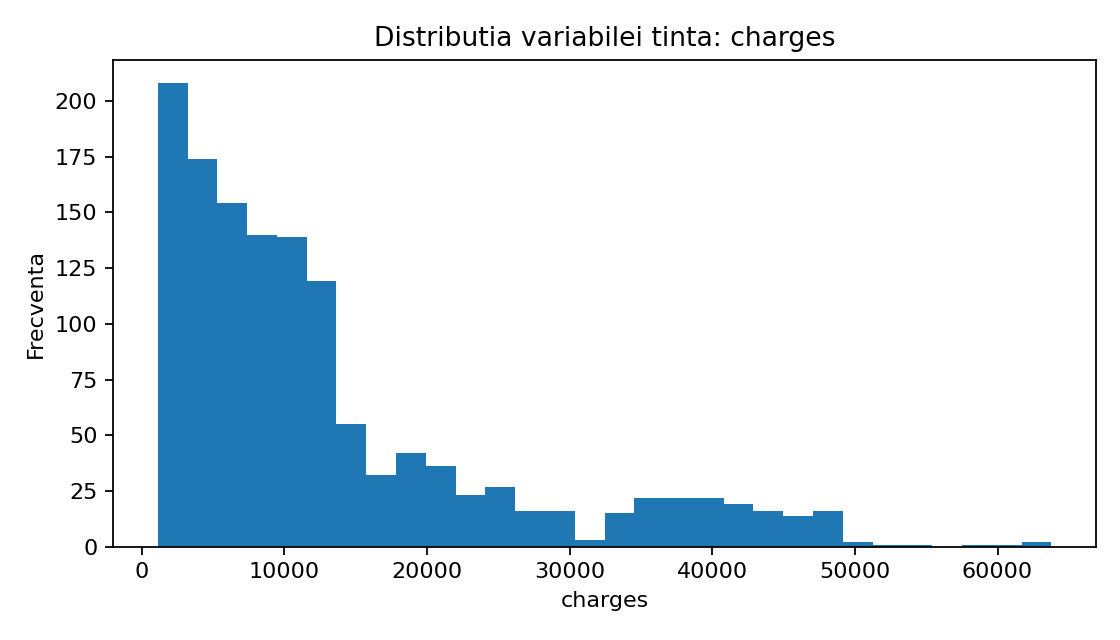

numeric_distributions: c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\eda\02_numeric_distributions.png


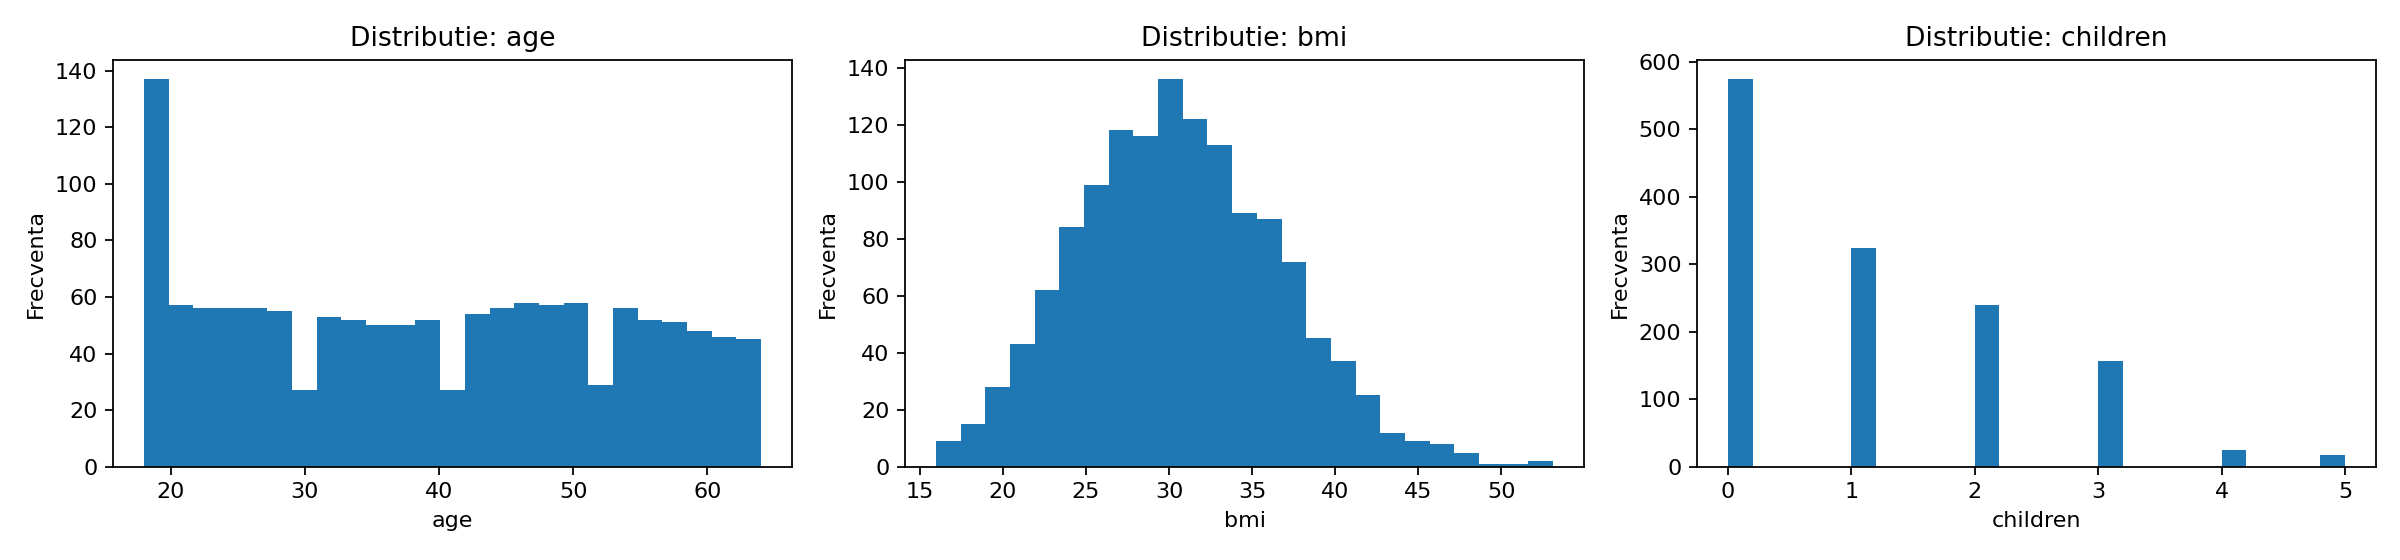

categorical_frequencies: c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\eda\03_categorical_frequencies.png


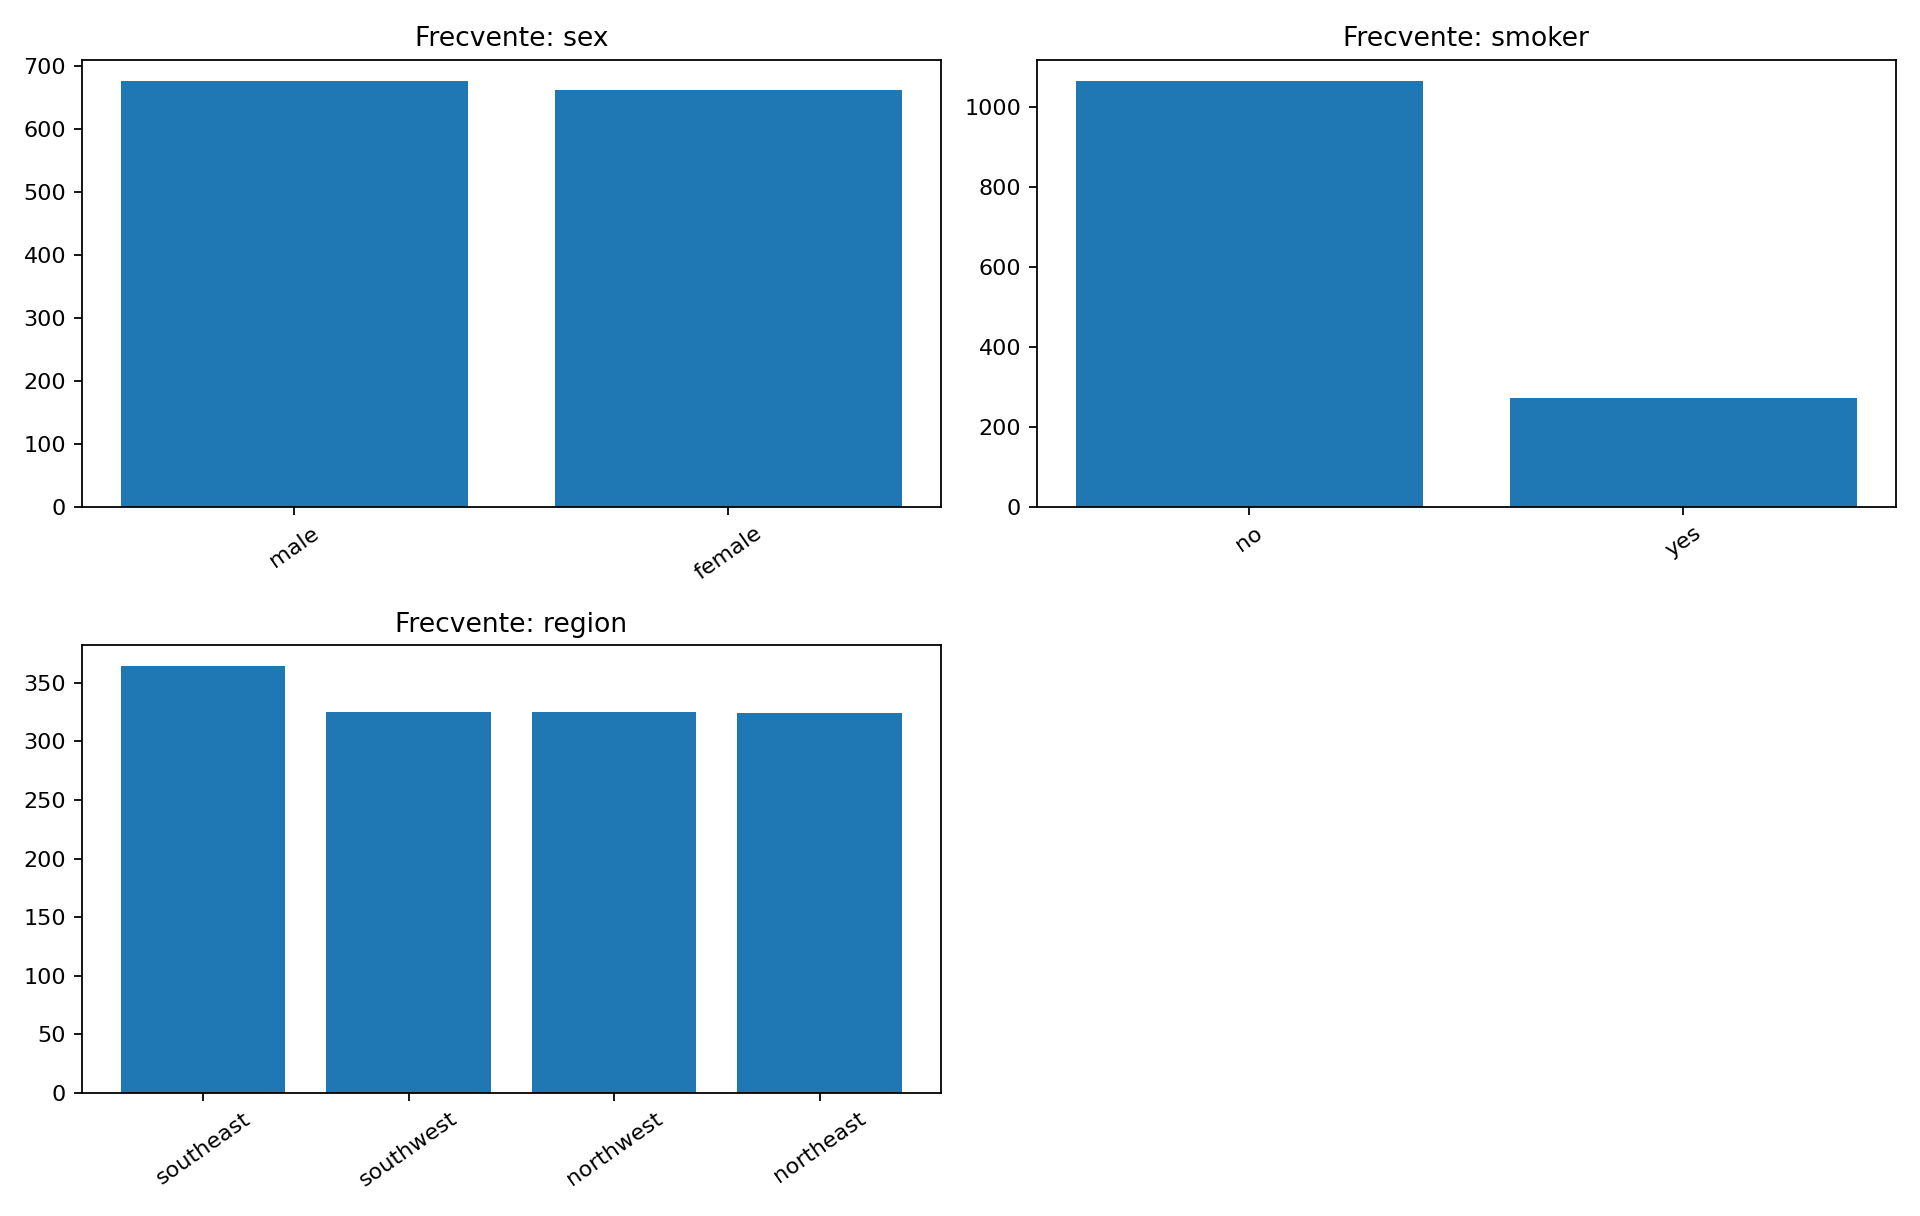

correlation_matrix: c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\eda\04_correlation_matrix.png


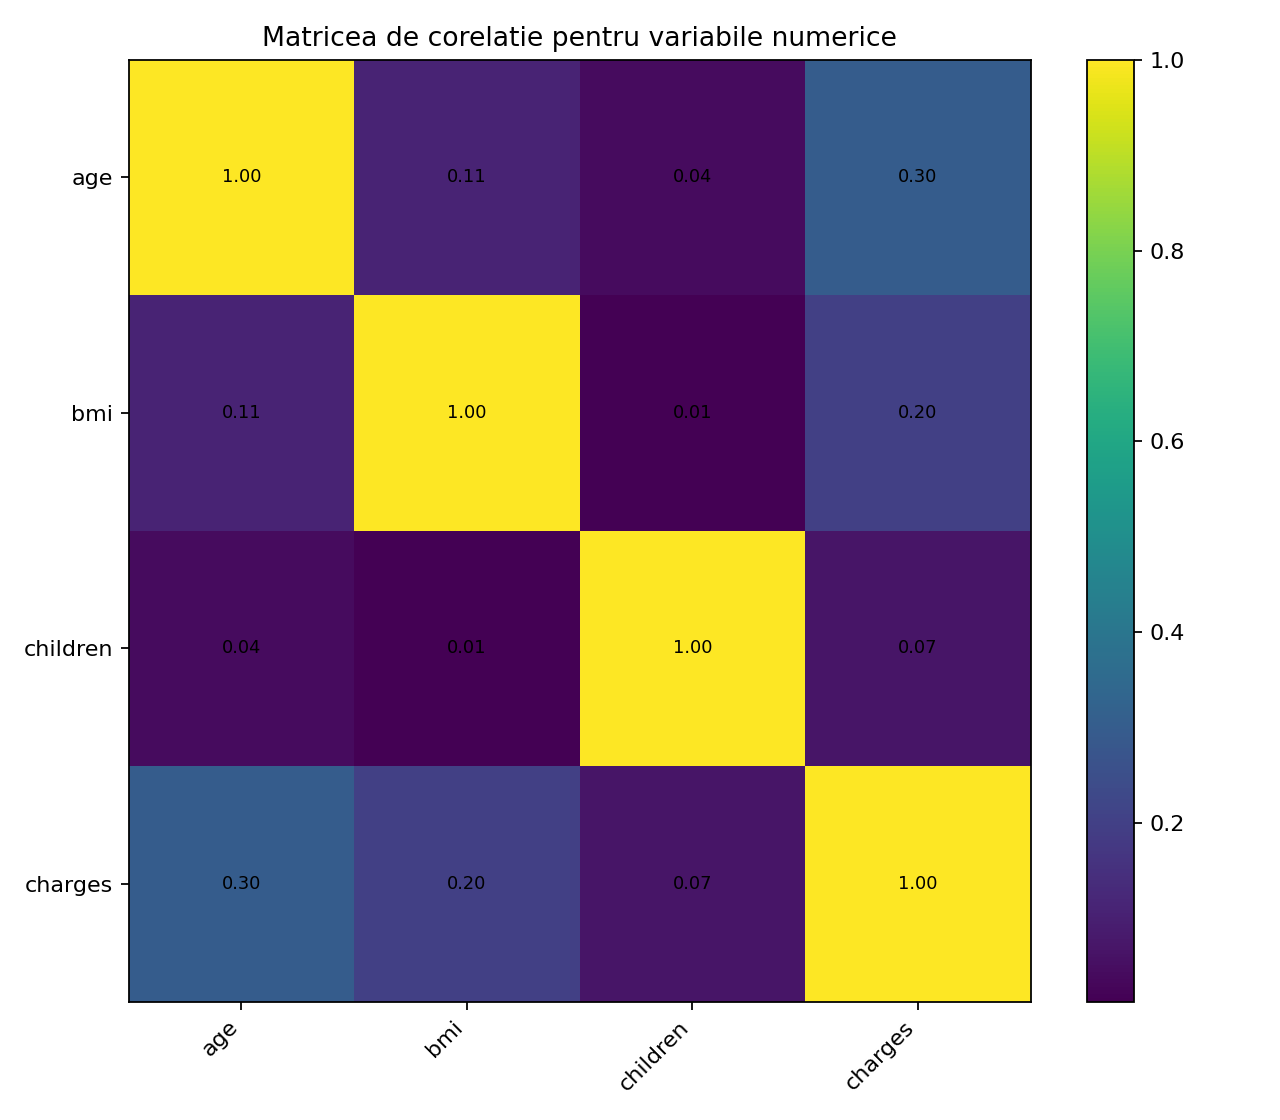

numeric_target_relationships: c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\eda\05_numeric_target_relationships.png


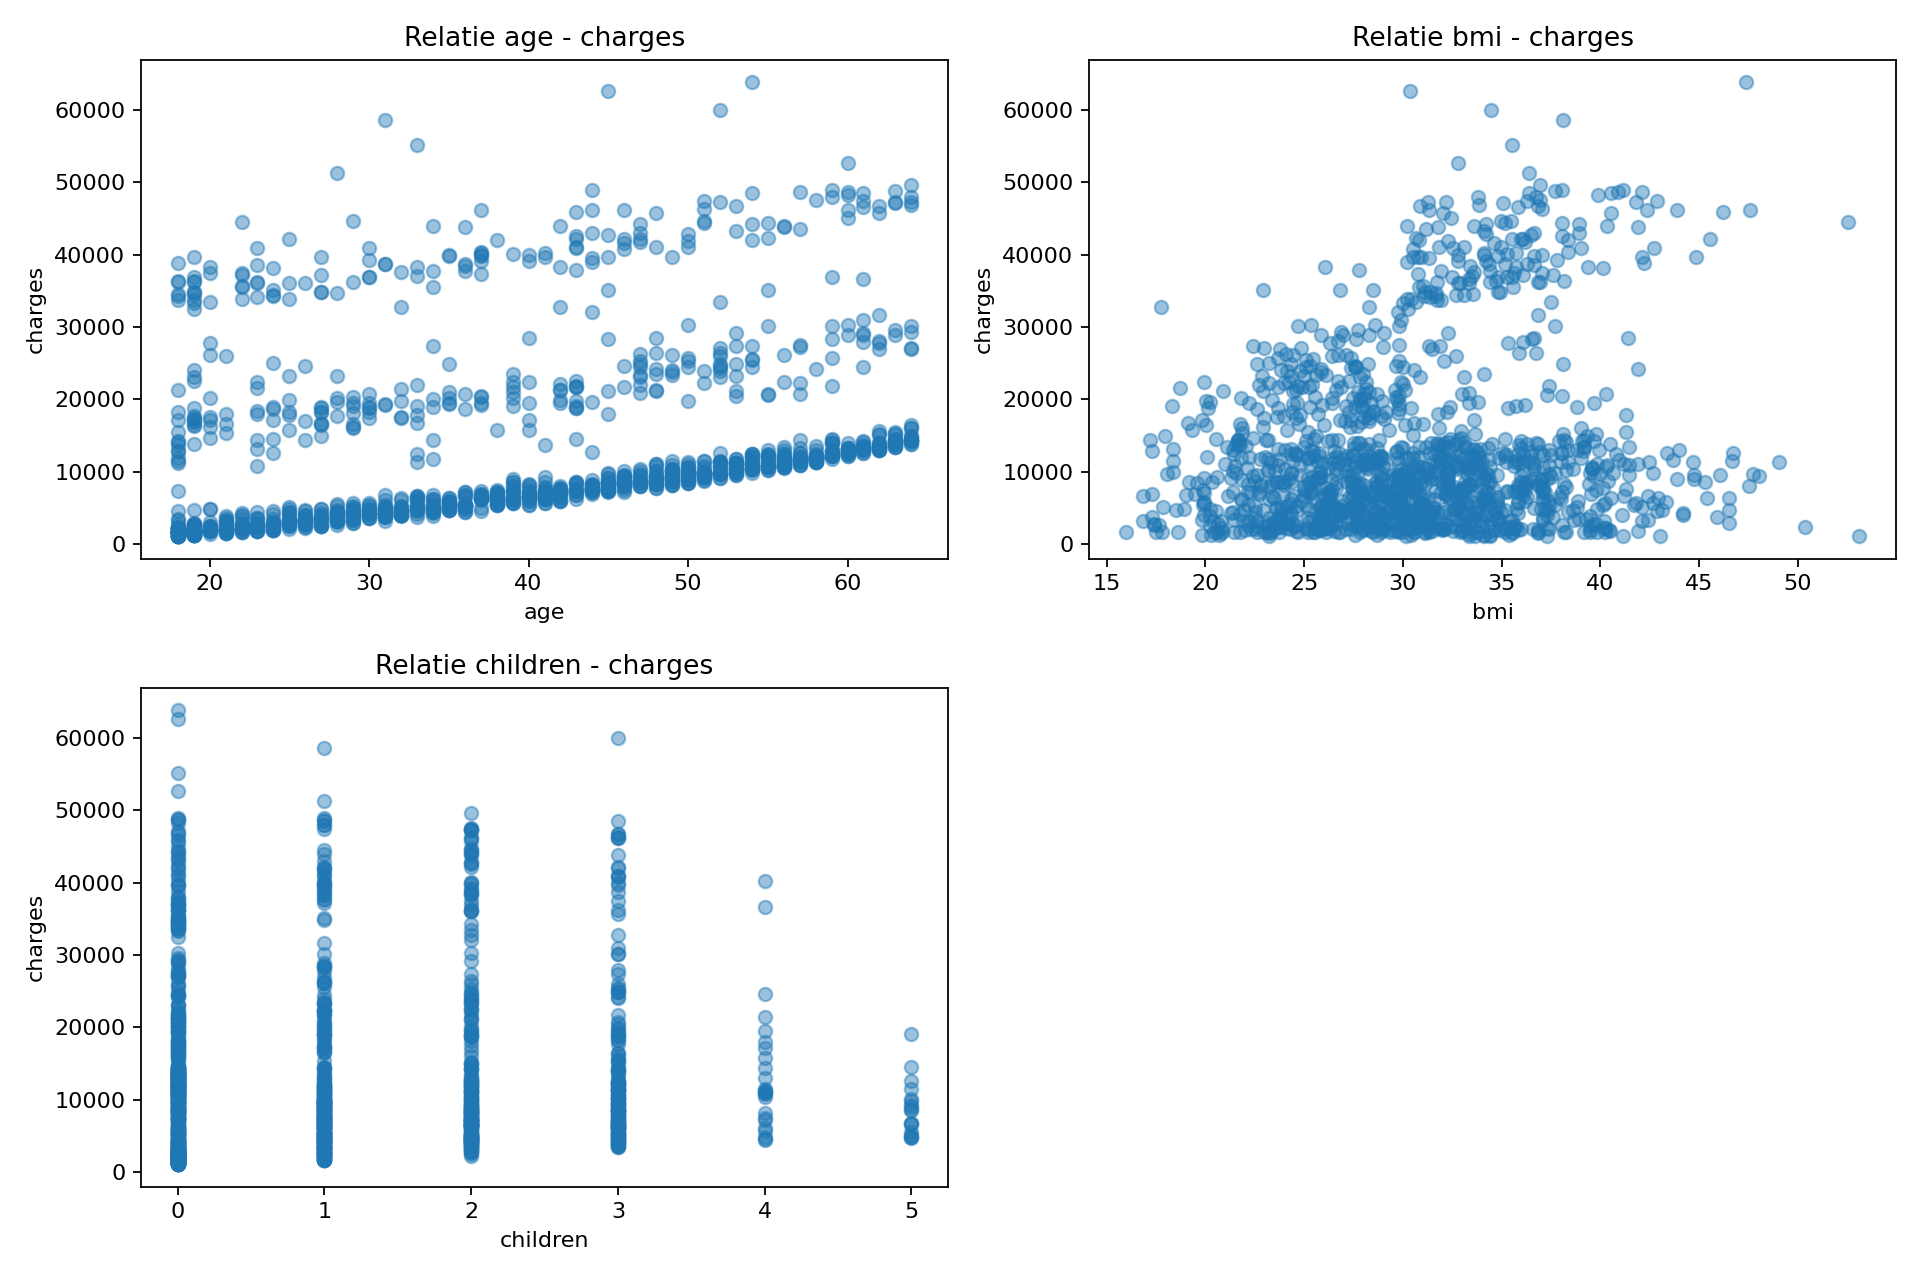

In [4]:
eda_dir = OUTPUT_ROOT / "regression" / "figures" / "eda"
eda_paths = save_eda_plots(df, "charges", "regression", eda_dir)

for name, path in eda_paths.items():
    print(f"{name}: {path}")
    display(Image(filename=path))


### Interpretare EDA

După analiza graficelor se urmăresc următoarele aspecte:

- dacă variabila țintă este echilibrată sau dezechilibrată;
- dacă există valori extreme care pot influența modelele;
- dacă variabilele numerice au distribuții apropiate de normalitate sau sunt asimetrice;
- dacă există relații vizibile între caracteristici și variabila țintă;
- dacă variabilele categorice trebuie codificate înainte de antrenare.

În acest proiect, preprocesarea se face automat printr-un `Pipeline`: valorile numerice sunt imputate și standardizate, iar valorile categorice sunt transformate prin one-hot encoding.


## 3. Împărțirea datelor și preprocesarea

Datele sunt împărțite în **75% pentru antrenare** și **25% pentru testare/validare**, conform cerinței. Pentru clasificare folosesc împărțire stratificată, astfel încât proporția claselor să rămână asemănătoare în train și test.


In [5]:
X_train, X_test, y_train, y_test = split_data(df, "charges", "regression", test_size=0.25, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (1003, 6)
X_test: (335, 6)


## 4. Antrenarea și compararea modelelor de bază

În această secțiune antrenez toate modelele cerute, folosind configurația de bază. Apoi calculez metricile relevante și le compar într-un tabel.


In [6]:
baseline_results, baseline_models = train_baseline_models("regression", X_train, X_test, y_train, y_test)

print("Rezultate baseline ordonate dupa metricile principale:")
display(baseline_results)

print("Top 5 modele baseline:")
display(baseline_results.head(5))


[Baseline] Antrenez: Linear Regression
[Baseline] Antrenez: Decision Tree Regressor
[Baseline] Antrenez: Random Forest Regressor
[Baseline] Antrenez: Support Vector Regressor
[Baseline] Antrenez: K-Nearest Neighbor Regressor
[Baseline] Antrenez: Gaussian Process Regressor
[Baseline] Antrenez: XGBoost Regressor
[Baseline] Antrenez: CatBoost Regressor
[Baseline] Antrenez: Explainable Boosting Regressor
Rezultate baseline ordonate dupa metricile principale:


,Model,MSE,MAE,RMSE,R2
0,Explainable Boosting Regressor,2.025484e+07,2512.955363,4500.537464,0.865765
1,CatBoost Regressor,2.174658e+07,2561.056877,4663.323154,0.855879
2,Random Forest Regressor,2.285737e+07,2607.167287,4780.938112,0.848517
3,XGBoost Regressor,2.463237e+07,2805.355143,4963.100430,0.836754
4,Linear Regression,3.511776e+07,4243.654117,5926.023602,0.767264
5,K-Nearest Neighbor Regressor,3.525600e+07,3532.650869,5937.676384,0.766348
6,Decision Tree Regressor,3.849071e+07,2758.387902,6204.088570,0.744911
7,Support Vector Regressor,1.650726e+08,8478.456762,12848.059486,-0.093985
8,Gaussian Process Regressor,7.868714e+11,231417.166884,887057.729879,-5213.828503


Top 5 modele baseline:


,Model,MSE,MAE,RMSE,R2
0,Explainable Boosting Regressor,2.025484e+07,2512.955363,4500.537464,0.865765
1,CatBoost Regressor,2.174658e+07,2561.056877,4663.323154,0.855879
2,Random Forest Regressor,2.285737e+07,2607.167287,4780.938112,0.848517
3,XGBoost Regressor,2.463237e+07,2805.355143,4963.100430,0.836754
4,Linear Regression,3.511776e+07,4243.654117,5926.023602,0.767264


### Concluzie pentru modelele de bază

Tabelul anterior compară toți algoritmii după metricile relevante pentru problema de regresie. Modelele sunt ordonate după RMSE, MAE și R². Primele poziții indică modelele care au avut cea mai bună performanță inițială, înainte de ajustarea hiperparametrilor.

Observația importantă este că performanța baseline nu este neapărat performanța finală. Unele modele se pot îmbunătăți semnificativ după tuning, iar altele pot rămâne stabile.


## 5. Ajustarea hiperparametrilor pentru toți algoritmii

In [7]:
top_5_names = baseline_results['Model'].head(5).tolist()
top_5_models = {name: baseline_models[name] for name in top_5_names}

tuned_results, tuned_models, best_params = tune_all_models(
    "regression",
    top_5_models,
    X_train,
    X_test,
    y_train,
    y_test,
    cv=3,
    n_iter_bayes=12,
    random_state=42,
)

print("Rezultate dupa tuning, ordonate dupa metricile principale:")
display(tuned_results)

print("Hiperparametrii gasiti:")
for model_name, params in best_params.items():
    print("", model_name)
    print(params)


[Tuning] Ajustez: Explainable Boosting Regressor
[Tuning] Ajustez: CatBoost Regressor
[Tuning] Ajustez: Random Forest Regressor
[Tuning] Ajustez: XGBoost Regressor
[Tuning] Ajustez: Linear Regression
Rezultate dupa tuning, ordonate dupa metricile principale:


,Model,MSE,MAE,RMSE,R2
0,Explainable Boosting Regressor,1.917577e+07,2391.524029,4379.014782,0.872917
1,CatBoost Regressor,1.954291e+07,2415.289104,4420.736361,0.870483
2,XGBoost Regressor,1.995786e+07,2511.571856,4467.421577,0.867733
3,Random Forest Regressor,2.044563e+07,2573.349673,4521.684737,0.864501
4,Linear Regression,3.511776e+07,4243.654117,5926.023602,0.767264


Hiperparametrii gasiti:
 Explainable Boosting Regressor
{'model__interactions': '5', 'model__learning_rate': '0.005', 'model__max_bins': '256', 'model__max_leaves': '2'}
 CatBoost Regressor
{'model__depth': '3', 'model__iterations': '300', 'model__l2_leaf_reg': '1', 'model__learning_rate': '0.03'}
 Random Forest Regressor
{'model__max_depth': '5', 'model__max_features': 'None', 'model__min_samples_leaf': '4', 'model__min_samples_split': '10', 'model__n_estimators': '100'}
 XGBoost Regressor
{'model__colsample_bytree': '0.9', 'model__learning_rate': '0.03', 'model__max_depth': '2', 'model__n_estimators': '250', 'model__subsample': '0.9'}
 Linear Regression
{'model__fit_intercept': 'True'}


In [11]:
save_artifacts(
    task="regression",
    output_root=OUTPUT_ROOT,
    baseline_results=baseline_results,
    tuned_results=tuned_results,
    tuned_estimators=tuned_models,
    best_params=best_params,
    data_path=DATA_PATH,
    target="charges",
)


### Interpretarea tuningului

După ajustarea hiperparametrilor, compar din nou modelele. Modelul aflat pe prima poziție este cel mai bun conform metricii principale. Totuși, alegerea finală nu trebuie făcută doar după un singur scor: trebuie analizate și stabilitatea, diferența dintre train și validare, complexitatea modelului și interpretabilitatea.


## 6. Learning Curves
Analizăm curbele de învățare pentru a depista eventualul overfitting, apoi aplicăm SHAP ca să vedem cum influențează fiecare feature costul asigurării. La final, exportăm totul.


[Learning curve] Explainable Boosting Regressor
[Learning curve] CatBoost Regressor
[Learning curve] Random Forest Regressor
[Learning curve] XGBoost Regressor
[Learning curve] Linear Regression
Explainable Boosting Regressor -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\learning_curves\learning_curve_explainable_boosting_regressor.png


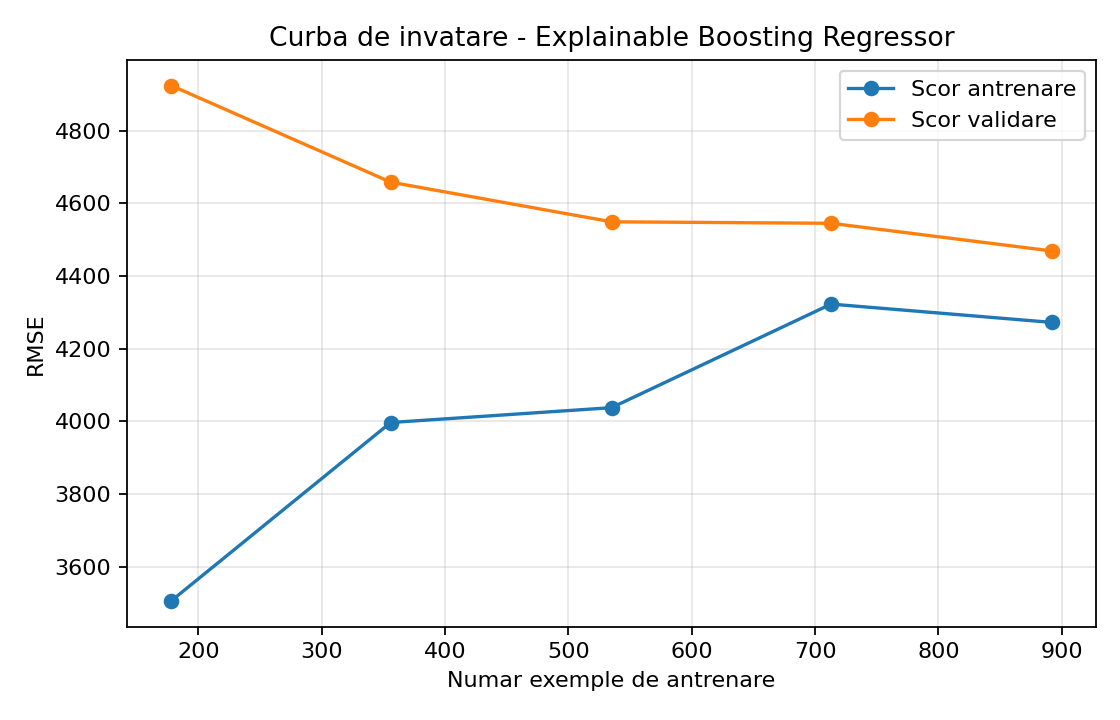

CatBoost Regressor -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\learning_curves\learning_curve_catboost_regressor.png


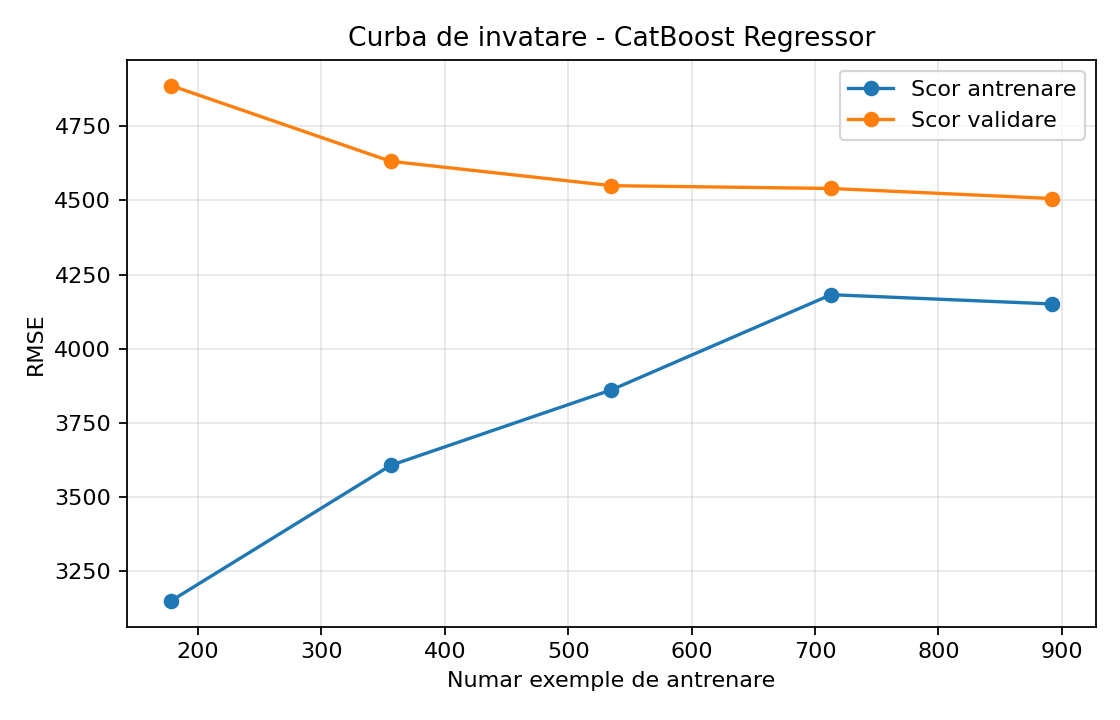

Random Forest Regressor -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\learning_curves\learning_curve_random_forest_regressor.png


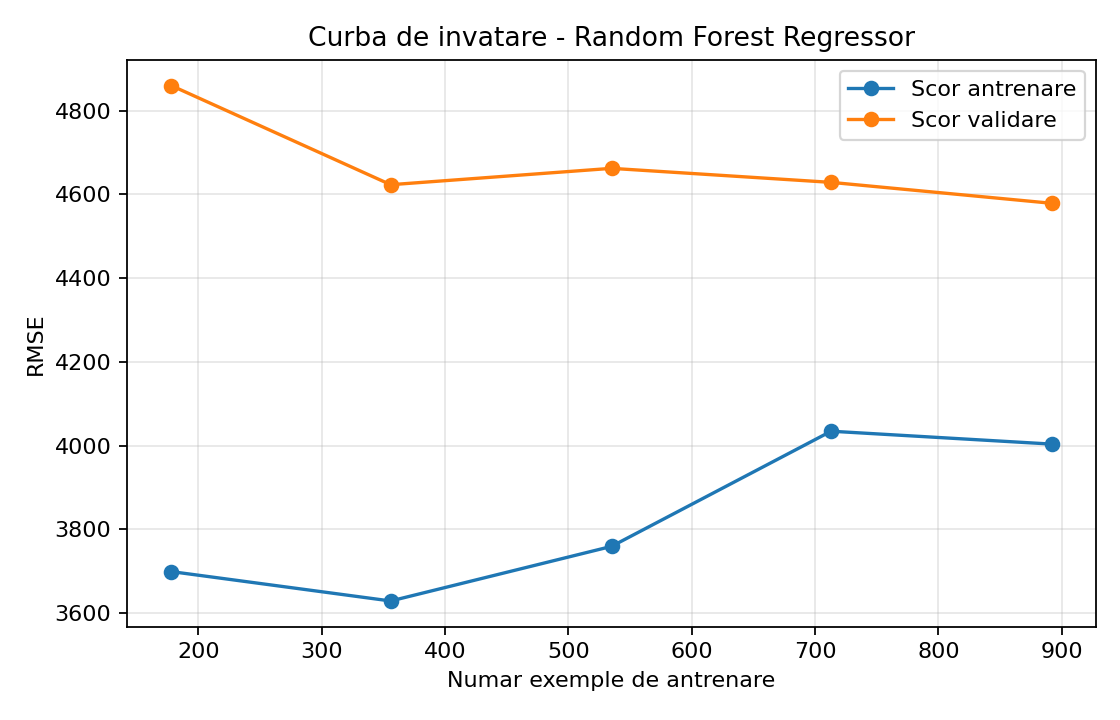

XGBoost Regressor -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\learning_curves\learning_curve_xgboost_regressor.png


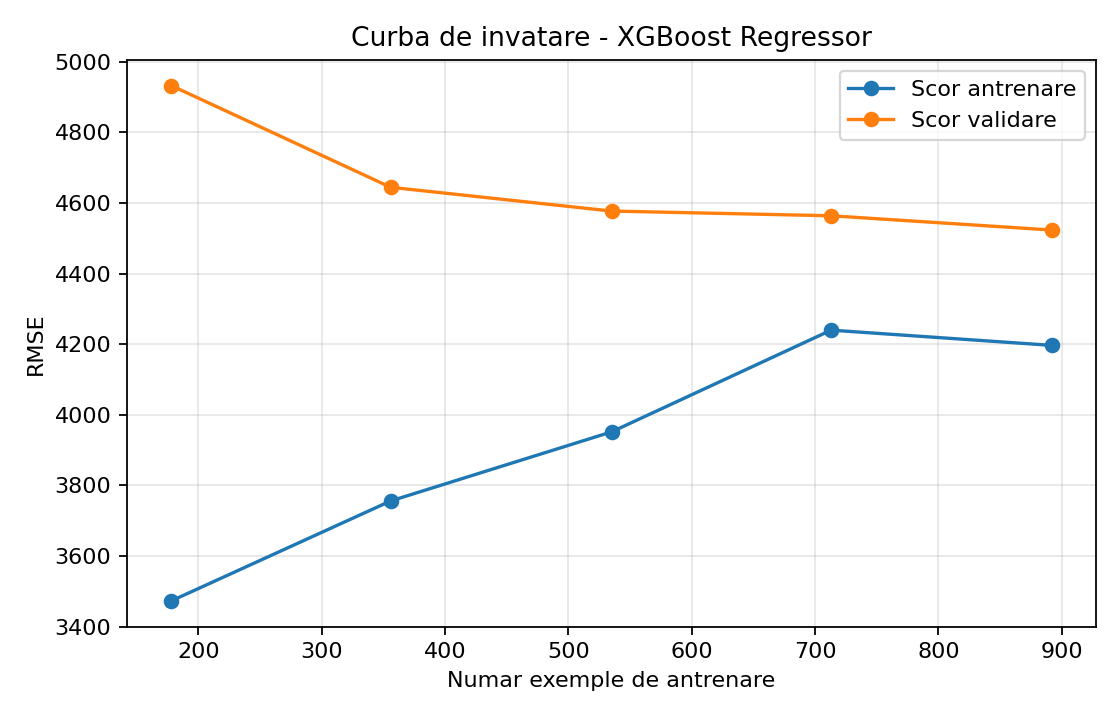

Linear Regression -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\learning_curves\learning_curve_linear_regression.png


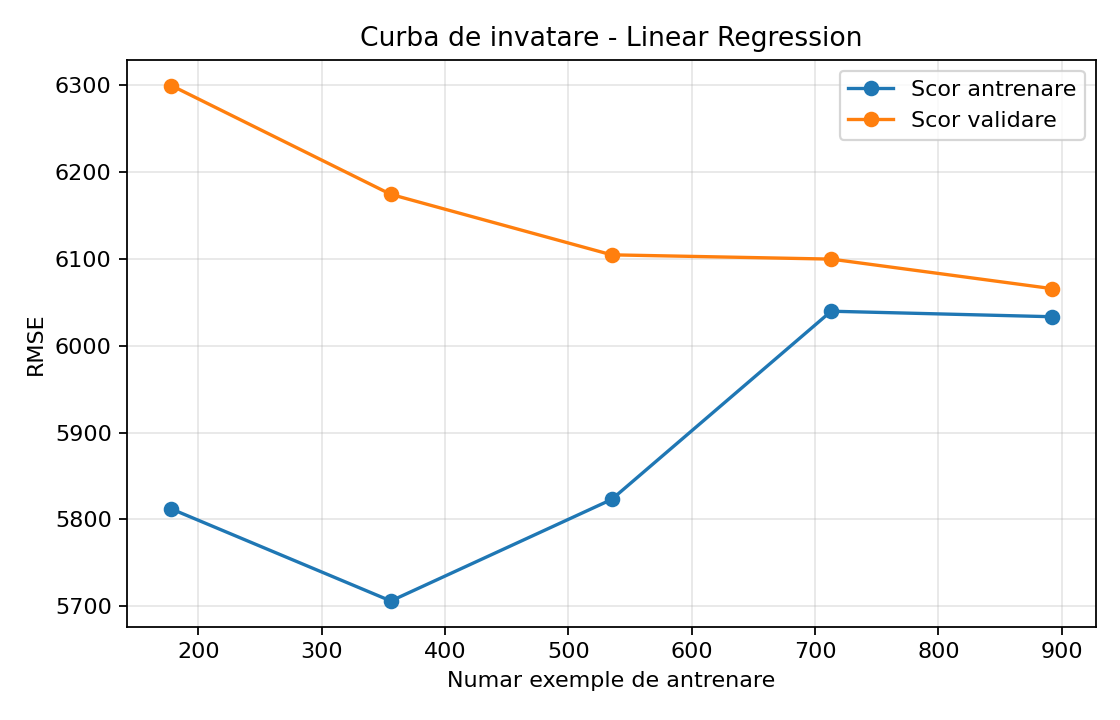

In [9]:
X_all = pd.concat([X_train, X_test], axis=0)
y_all = pd.concat([y_train, y_test], axis=0)

learning_dir = OUTPUT_ROOT / "regression" / "figures" / "learning_curves"
learning_paths = save_learning_curves("regression", tuned_models, X_all, y_all, learning_dir, cv=3)

for model_name, path in learning_paths.items():
    print(model_name, "->", path)
    display(Image(filename=path))


### Interpretarea curbelor de învățare

Pentru fiecare model urmăresc diferența dintre curba de antrenare și curba de validare:

- **overfitting**: scor foarte bun pe train, dar sensibil mai slab pe validare;
- **underfitting**: scor slab atât pe train, cât și pe validare;
- **generalizare bună**: cele două curbe sunt apropiate și au valori bune.

Dacă adăugarea de date reduce diferența dintre cele două curbe, modelul ar putea beneficia de mai multe date. Dacă diferența rămâne mare, poate fi nevoie de regularizare sau de un model mai simplu.


## 7. Explicabilitate SHAP pentru toți algoritmii

Cerința minimă solicită SHAP pentru primele 3 modele perfecționate. În acest notebook generez SHAP pentru **toate modelele ajustate**, folosind o abordare model-agnostic bazată pe permutation explainer, astfel încât să funcționeze pentru orice algoritm.

Pentru fiecare model sunt generate:

- `summary plot`;
- `bar plot`;
- `waterfall plot` pentru o predicție locală;
- `force plot` pentru o predicție locală;
- `scatter plot` pentru 2–3 caracteristici importante;
- fișier JSON cu cele mai importante 3 caracteristici.


[SHAP] Explainable Boosting Regressor
[SHAP] CatBoost Regressor
[SHAP] Random Forest Regressor


PermutationExplainer explainer: 81it [00:11,  1.02it/s]                        


[SHAP] XGBoost Regressor
[SHAP] Linear Regression
=== Explainable Boosting Regressor ===
summary -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_summary_explainable_boosting_regressor.png


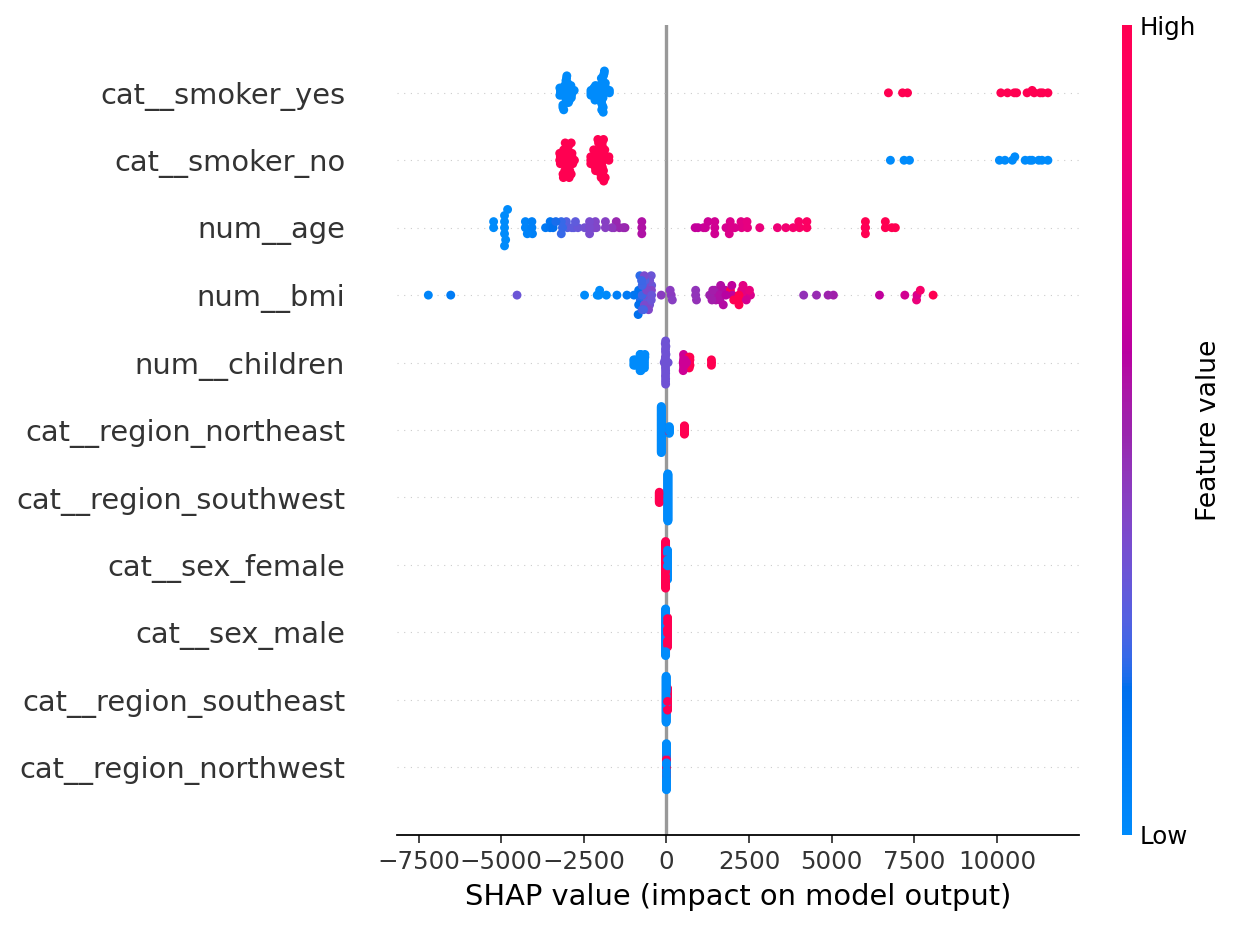

bar -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_bar_explainable_boosting_regressor.png


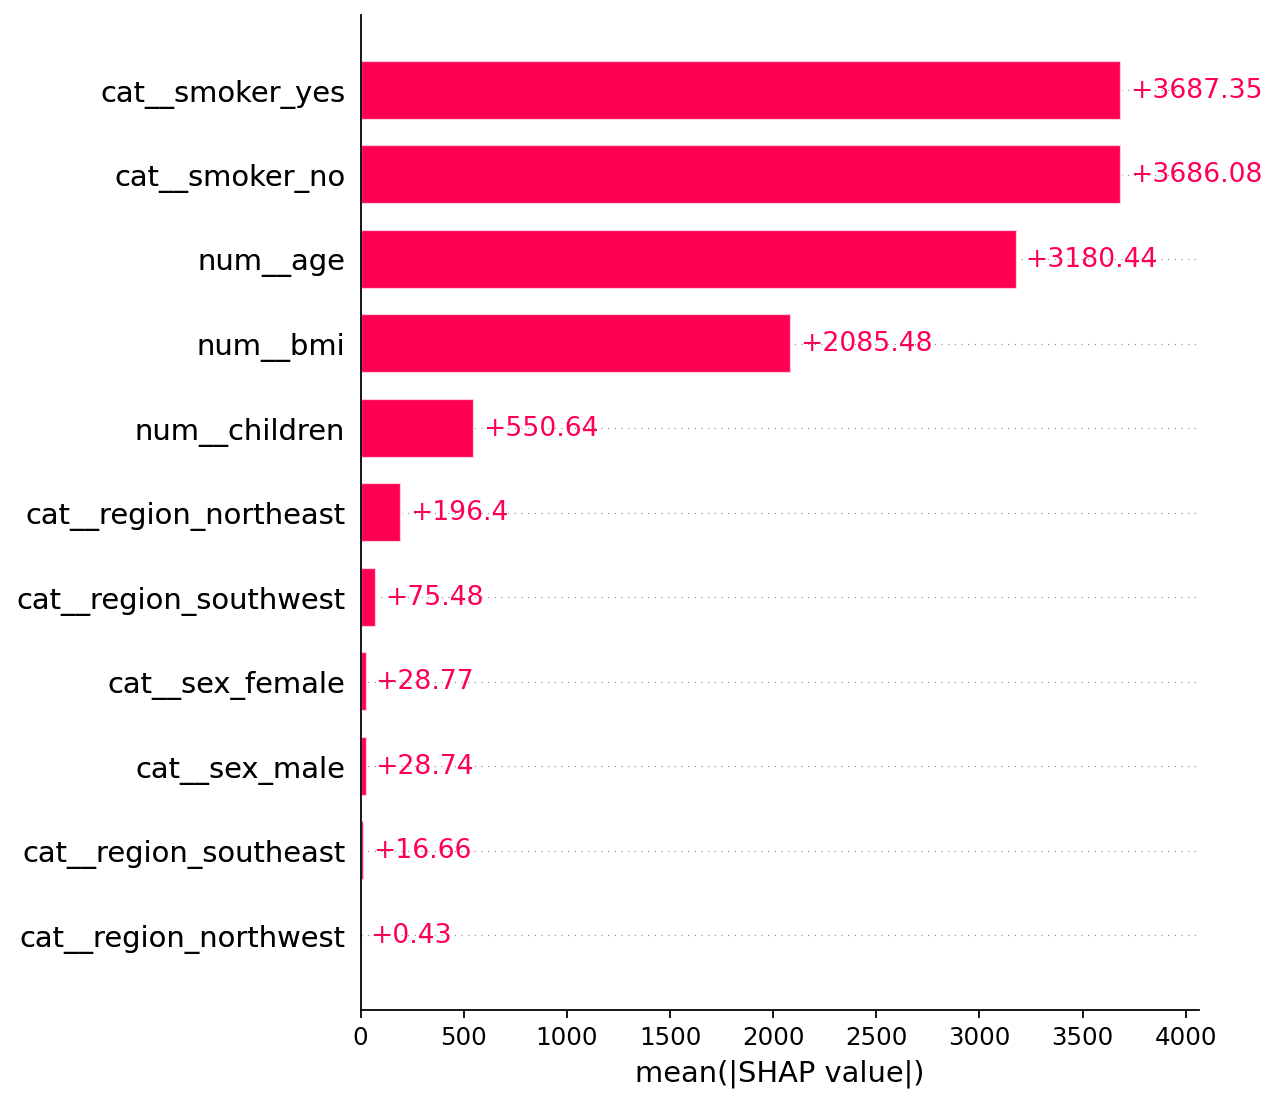

waterfall -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_waterfall_explainable_boosting_regressor.png


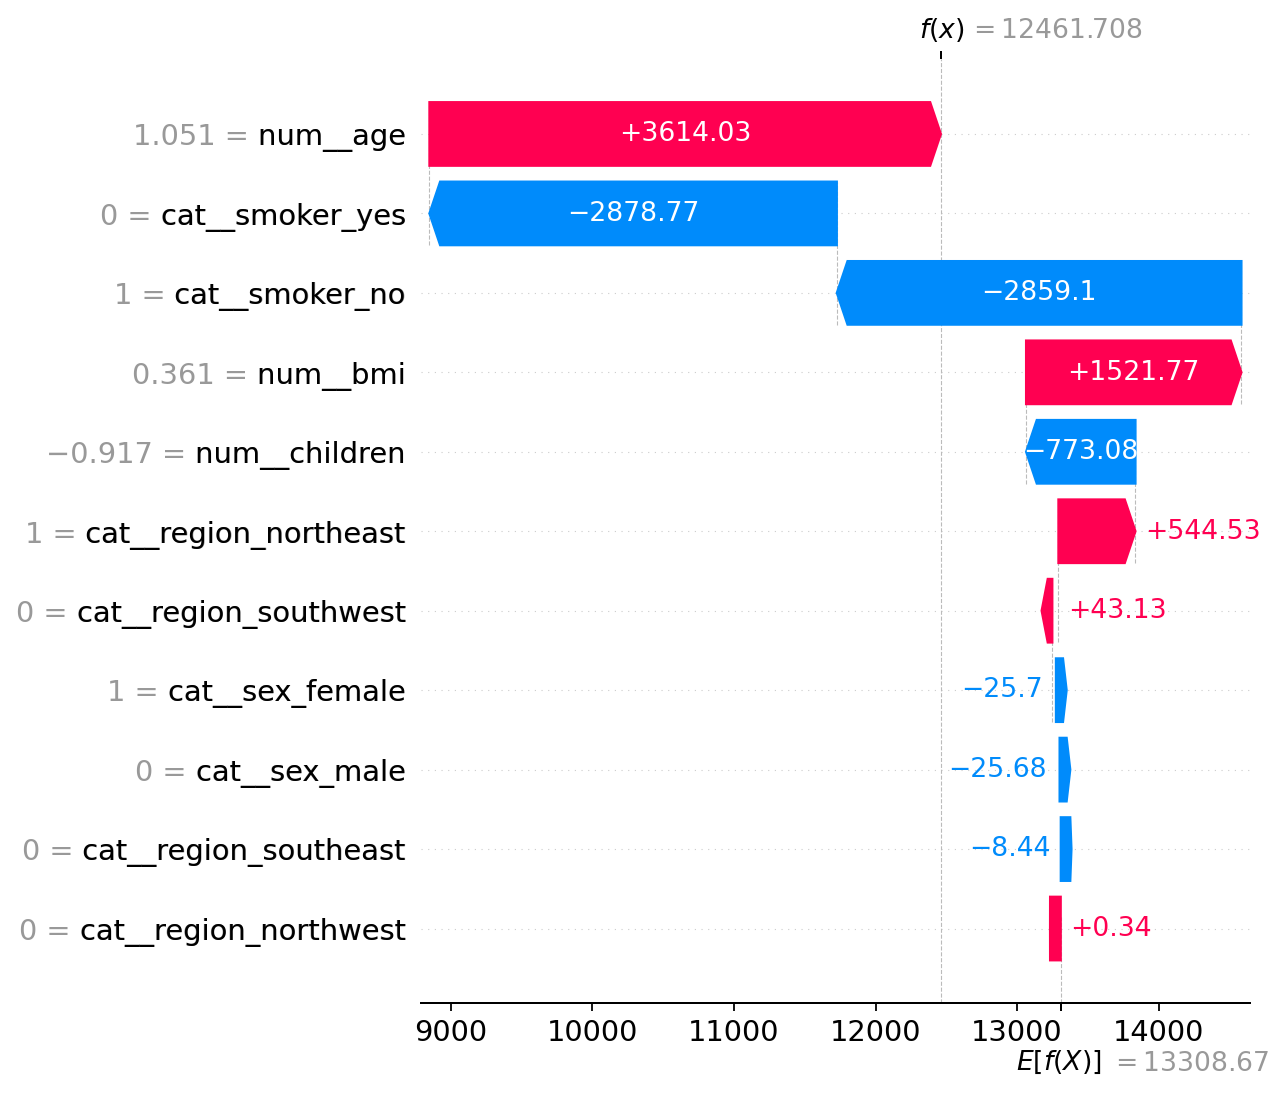

force -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_force_explainable_boosting_regressor.png


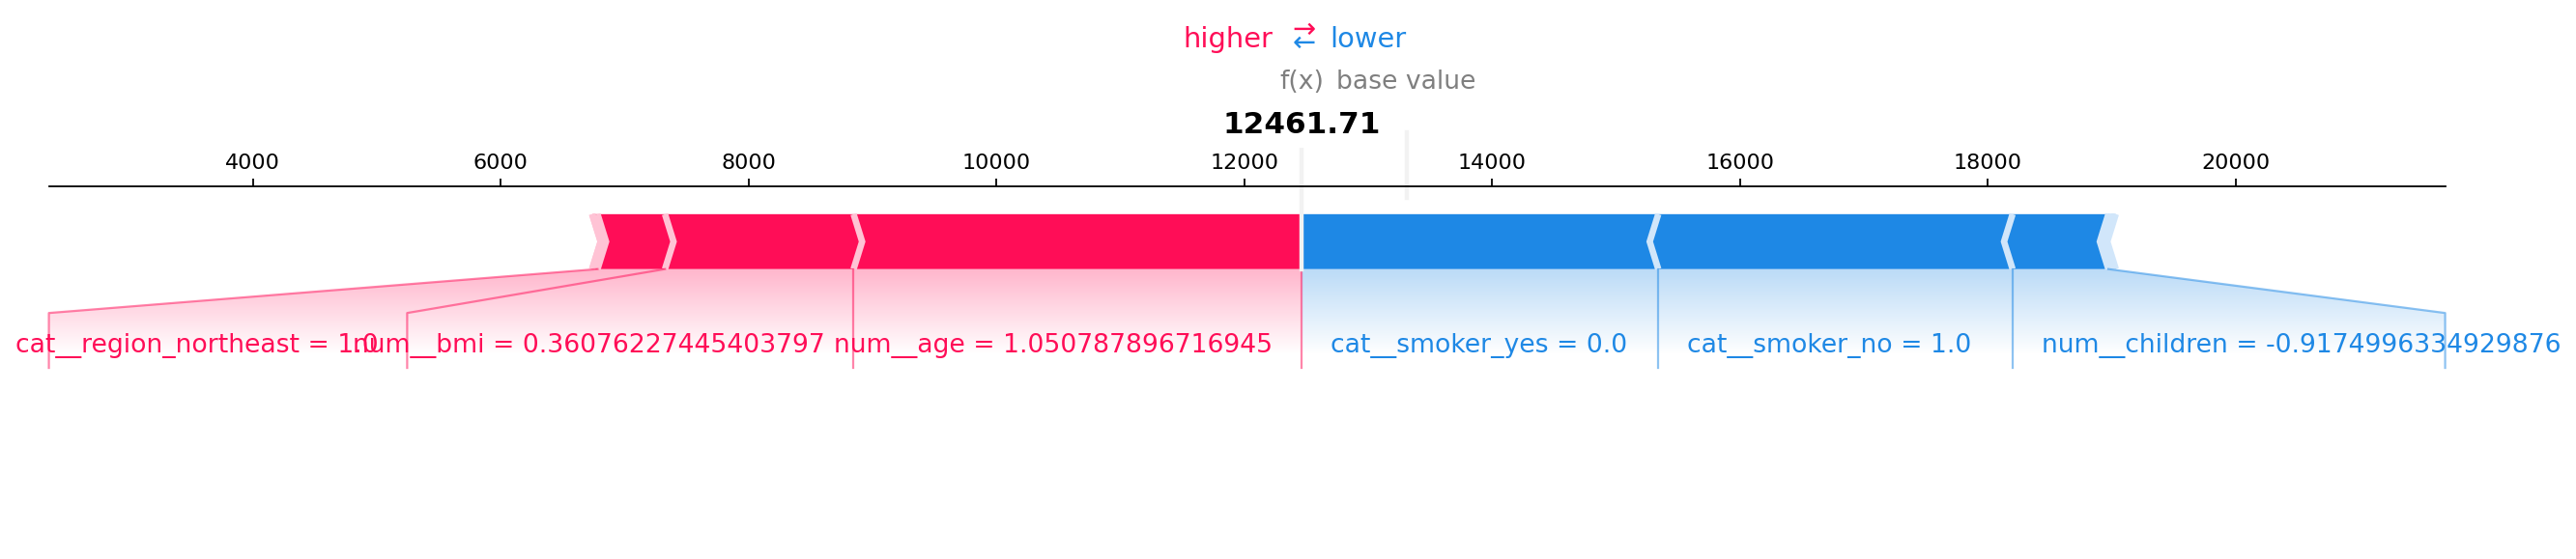

scatter -> ['c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_explainable_boosting_regressor_cat_smoker_yes.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_explainable_boosting_regressor_cat_smoker_no.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_explainable_boosting_regressor_num_age.png']
top_features_json -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_top_features_explainable_boosting_regressor.json
=== CatBoost Regressor ===
summary -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_summary_catboost_regressor.png


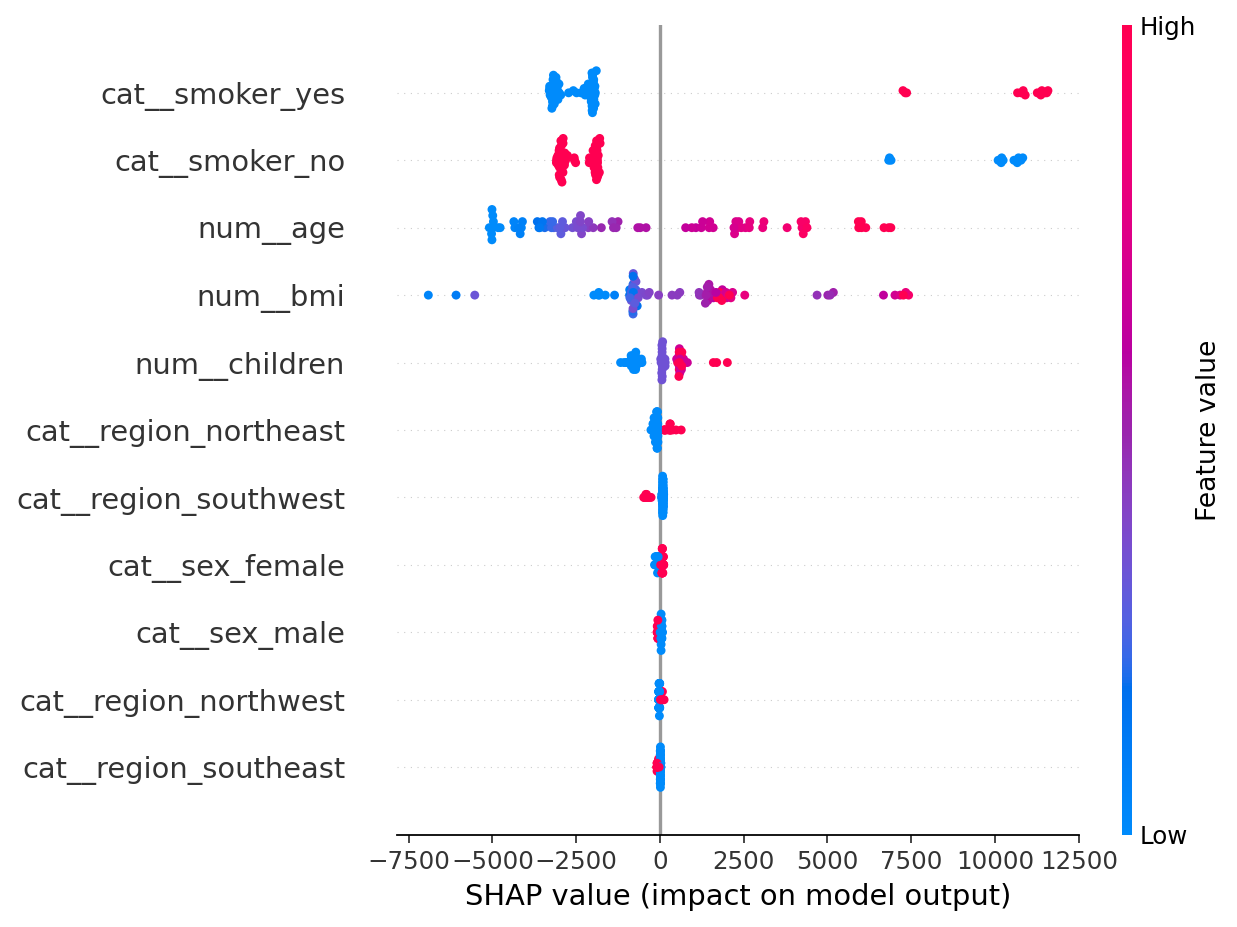

bar -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_bar_catboost_regressor.png


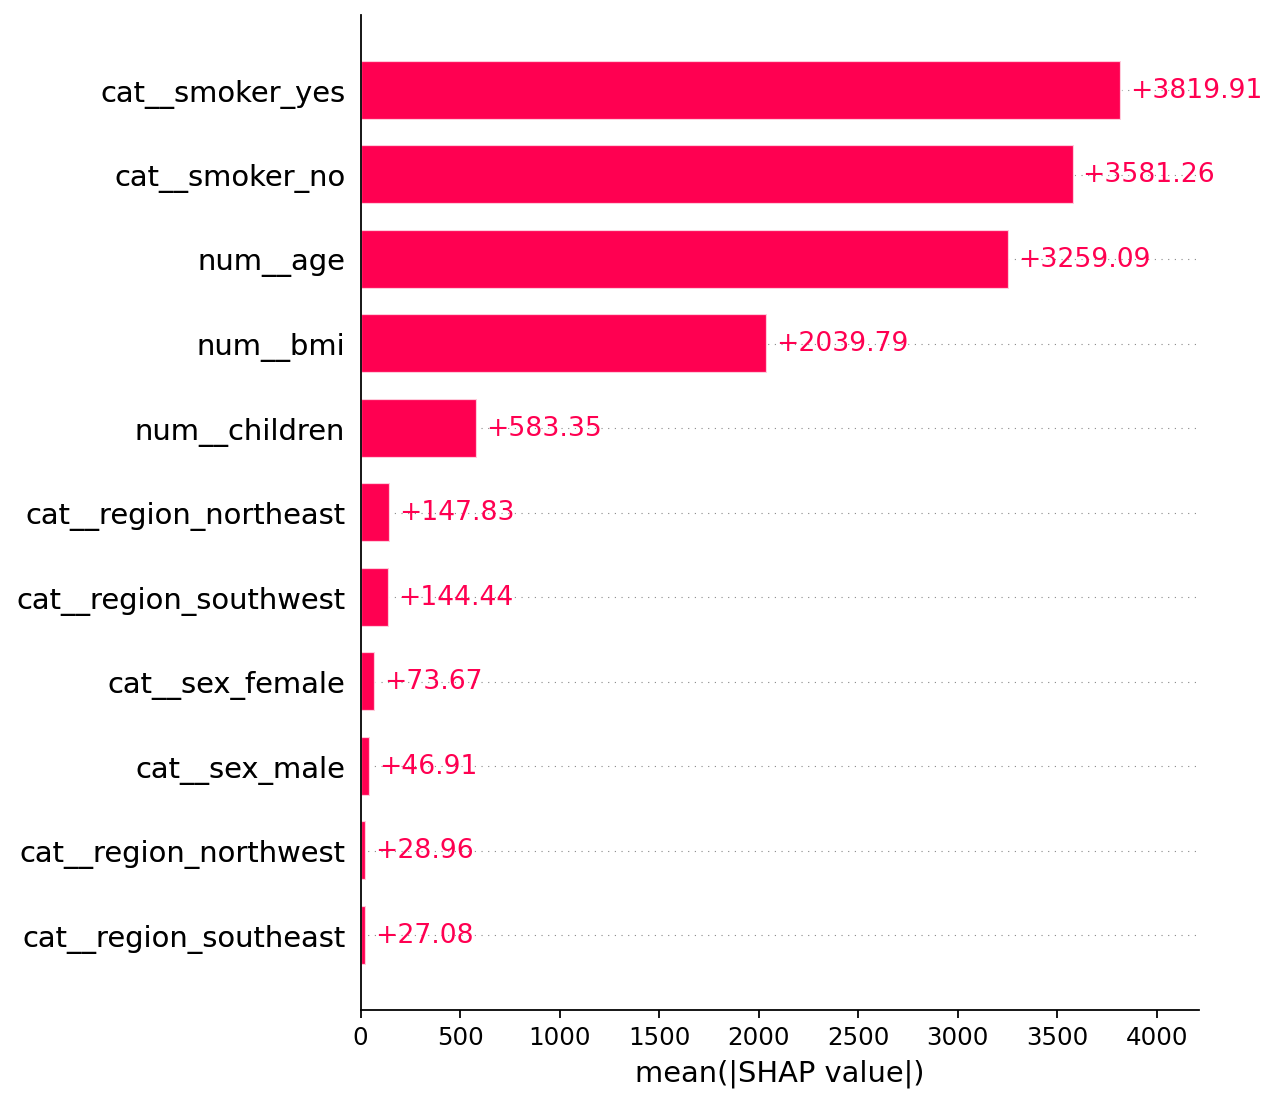

waterfall -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_waterfall_catboost_regressor.png


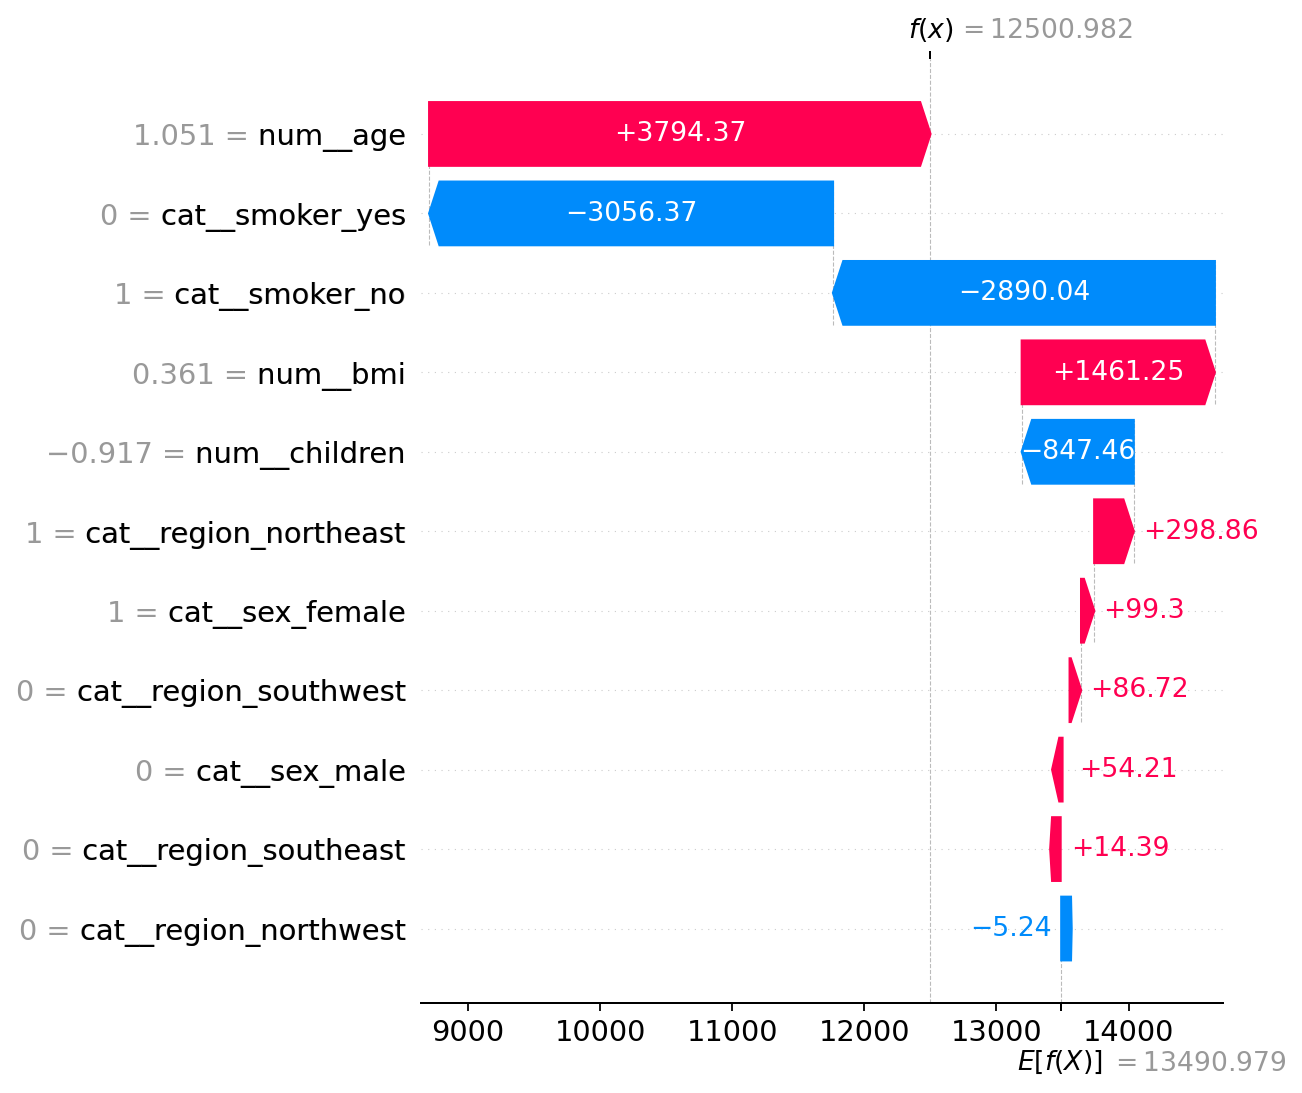

force -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_force_catboost_regressor.png


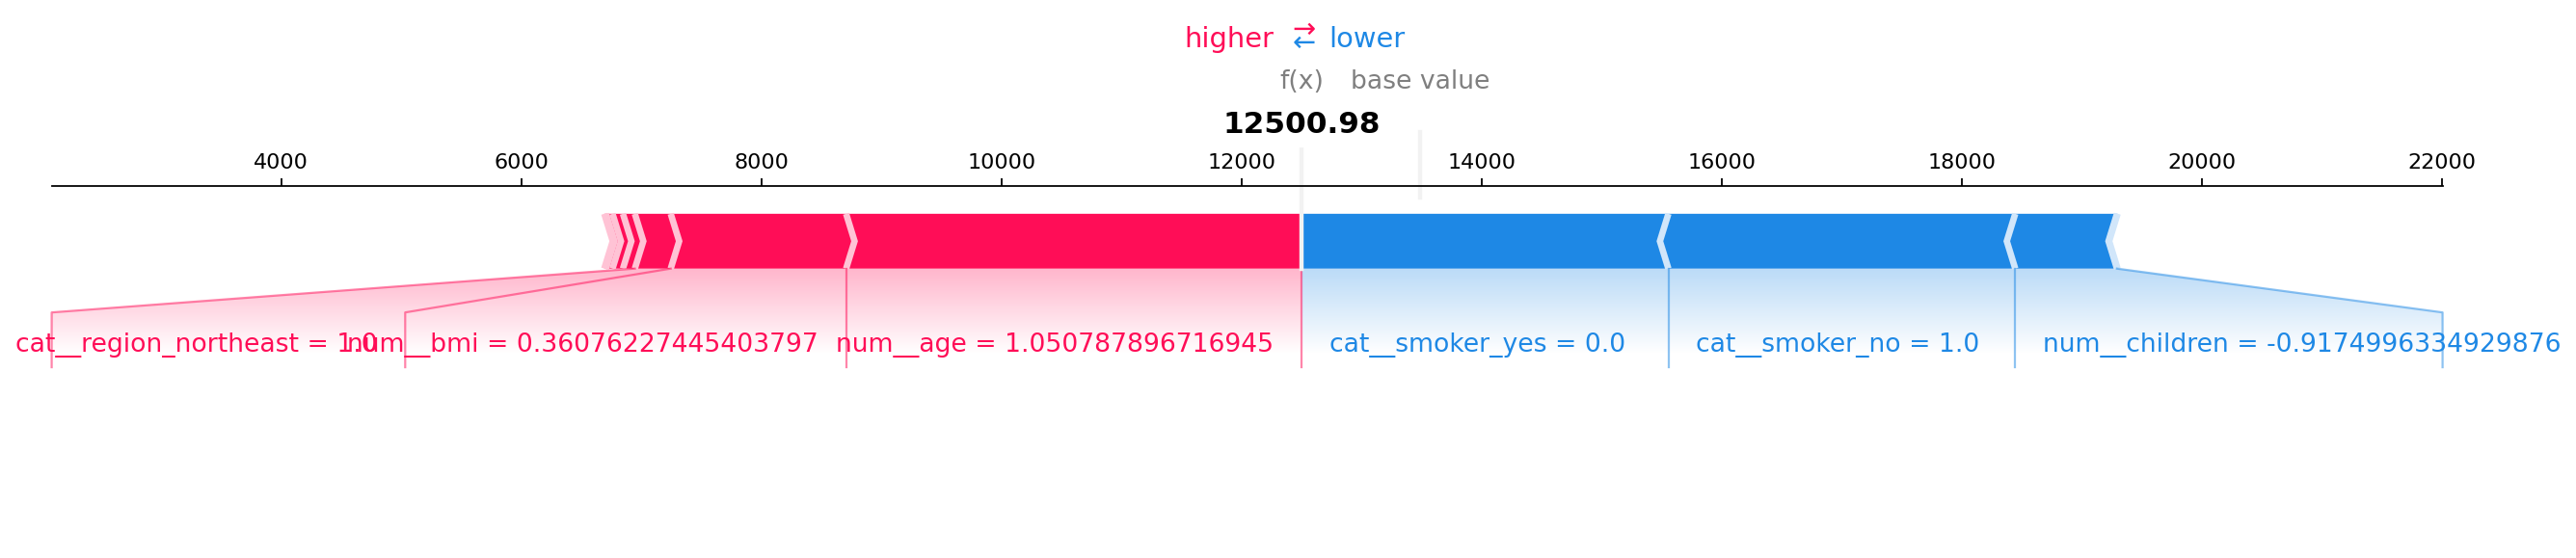

scatter -> ['c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_catboost_regressor_cat_smoker_yes.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_catboost_regressor_cat_smoker_no.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_catboost_regressor_num_age.png']
top_features_json -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_top_features_catboost_regressor.json
=== Random Forest Regressor ===
summary -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_summary_random_forest_regressor.png


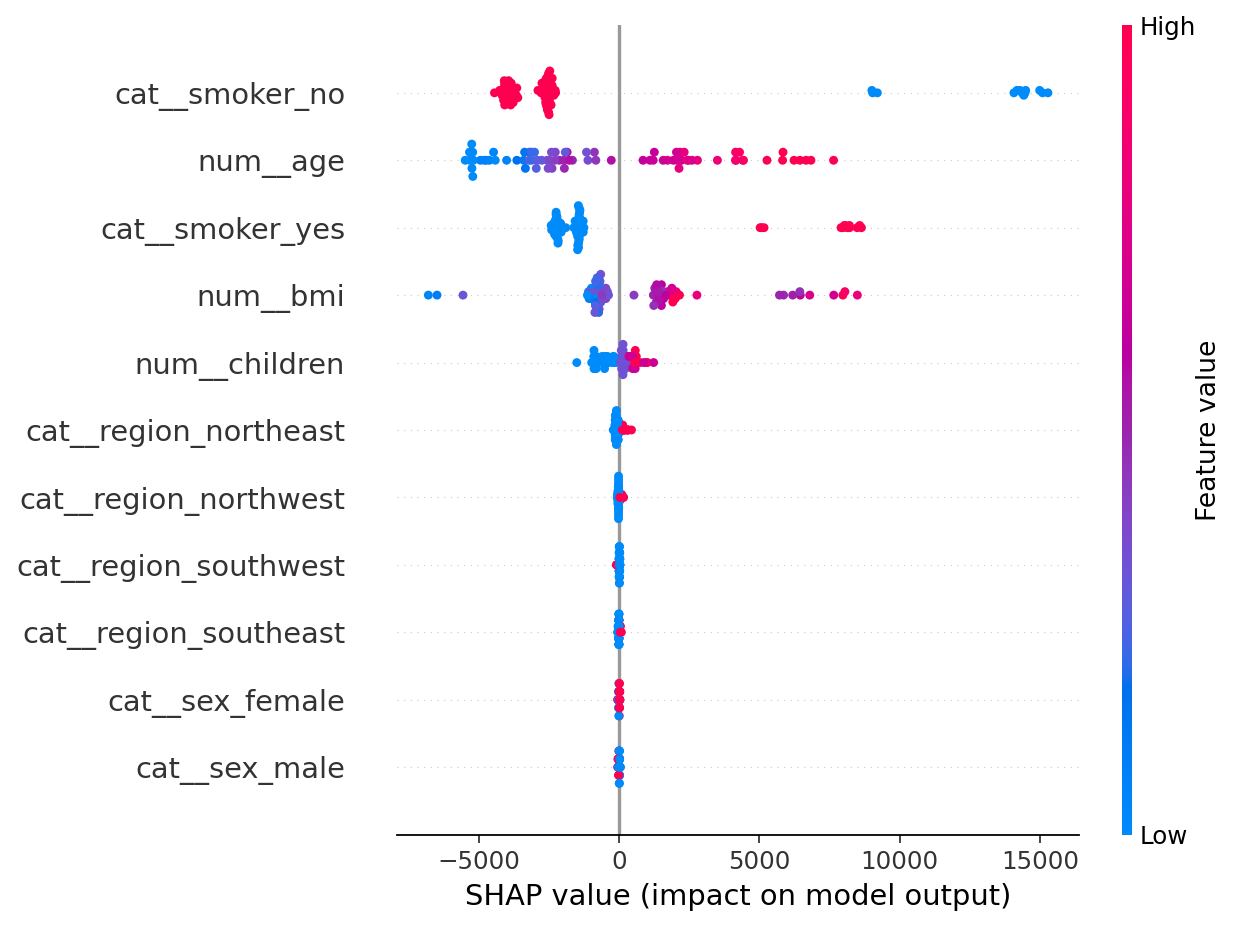

bar -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_bar_random_forest_regressor.png


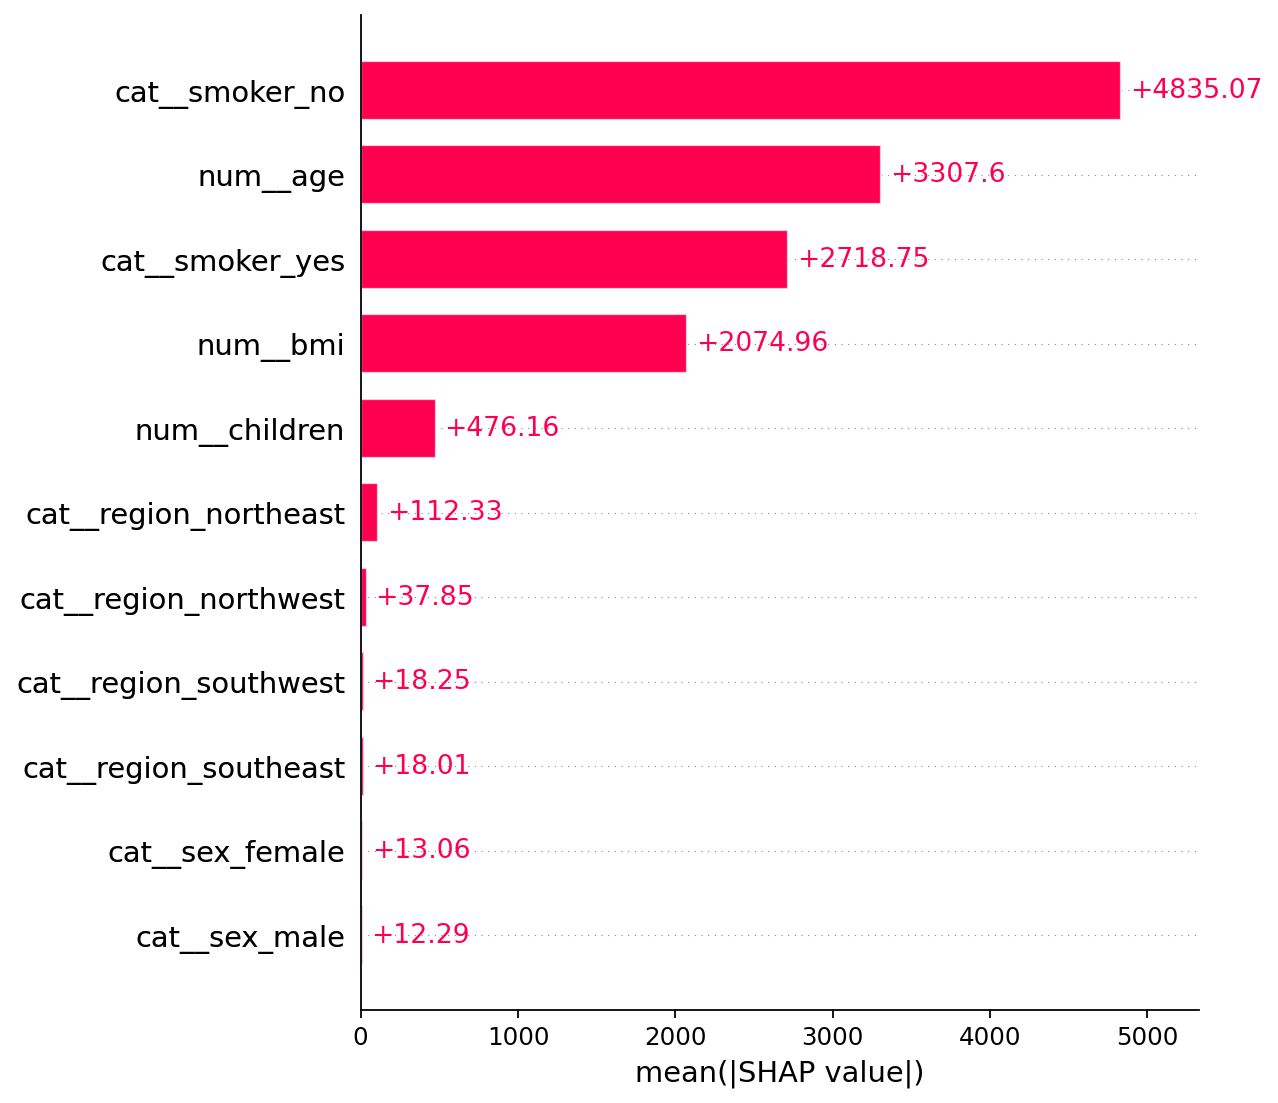

waterfall -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_waterfall_random_forest_regressor.png


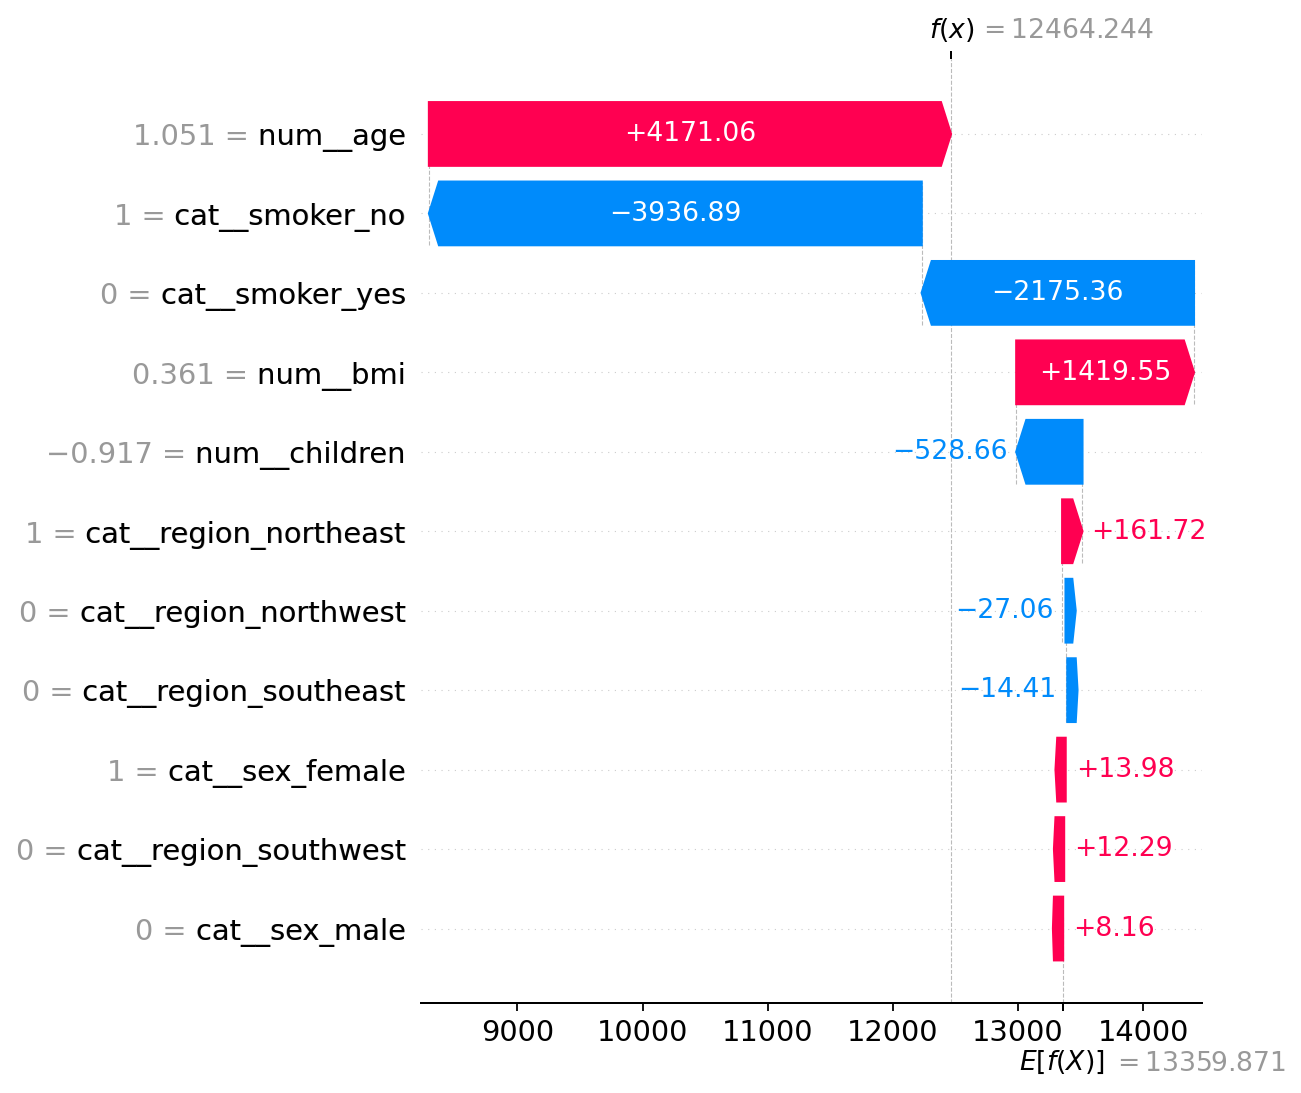

force -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_force_random_forest_regressor.png


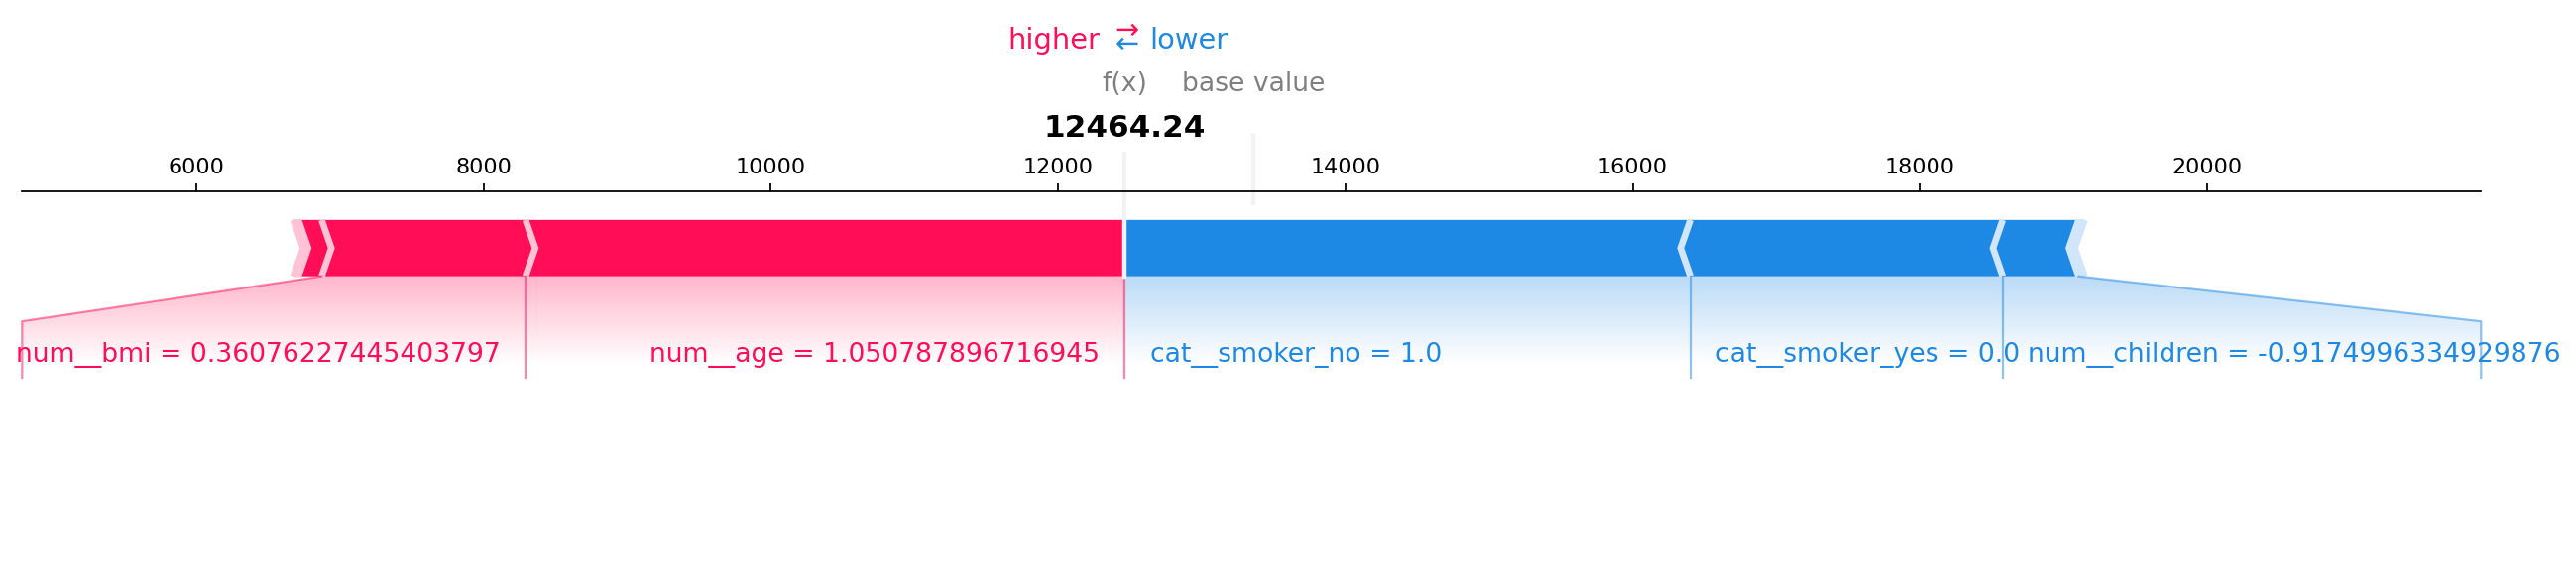

scatter -> ['c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_random_forest_regressor_cat_smoker_no.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_random_forest_regressor_num_age.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_random_forest_regressor_cat_smoker_yes.png']
top_features_json -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_top_features_random_forest_regressor.json
=== XGBoost Regressor ===
summary -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_summary_xgboost_regressor.png


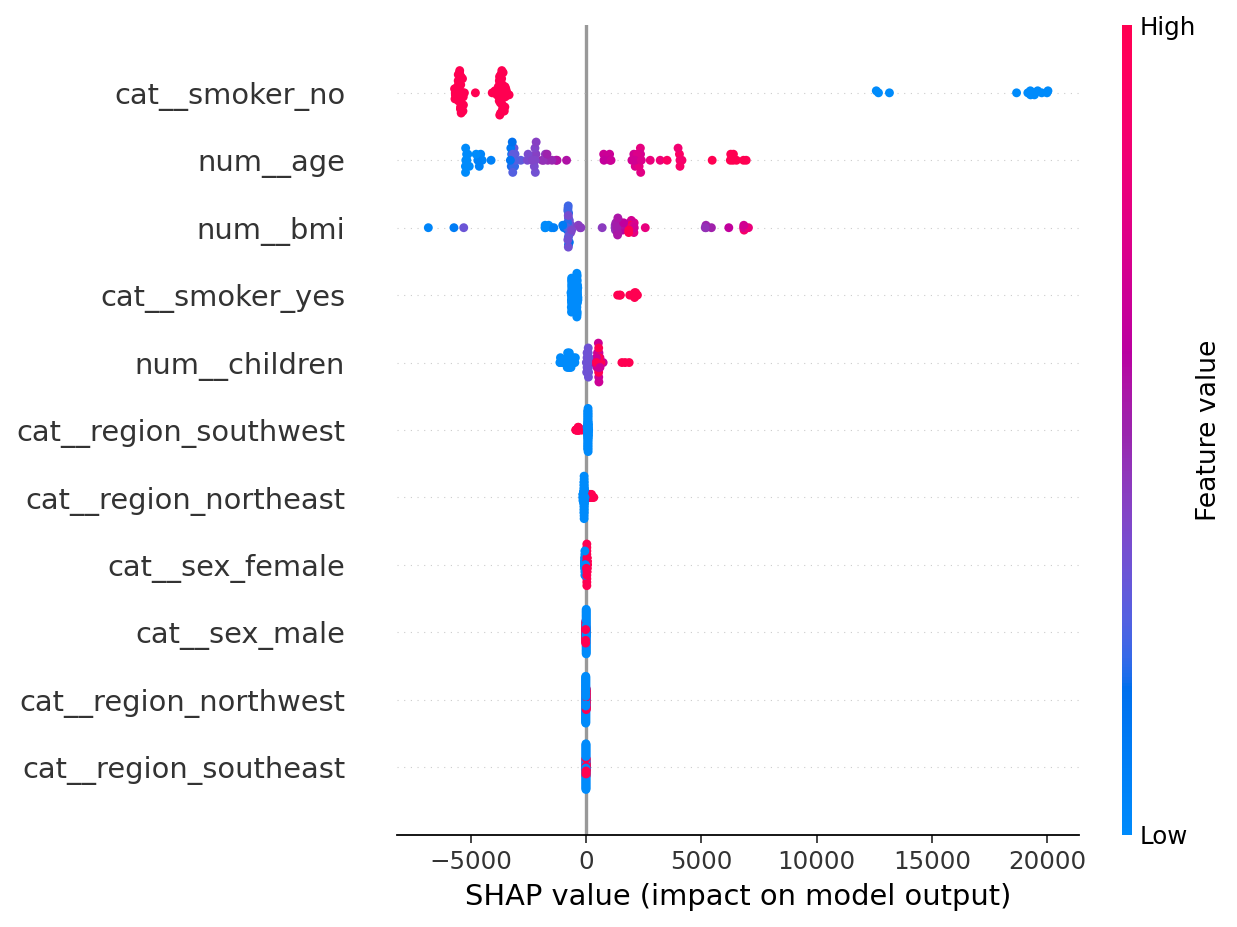

bar -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_bar_xgboost_regressor.png


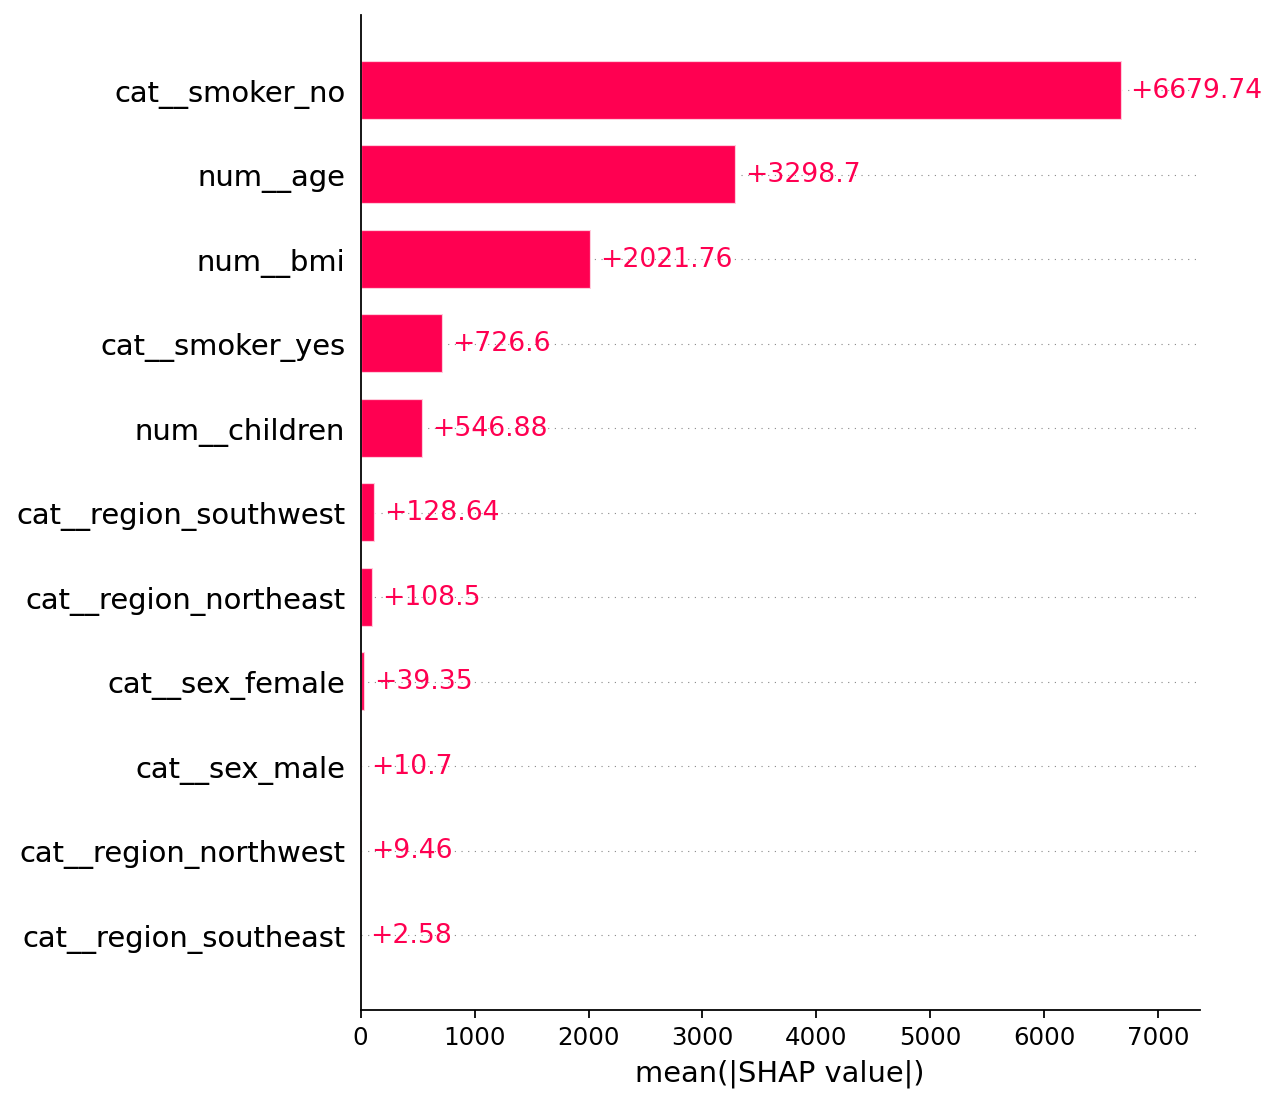

waterfall -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_waterfall_xgboost_regressor.png


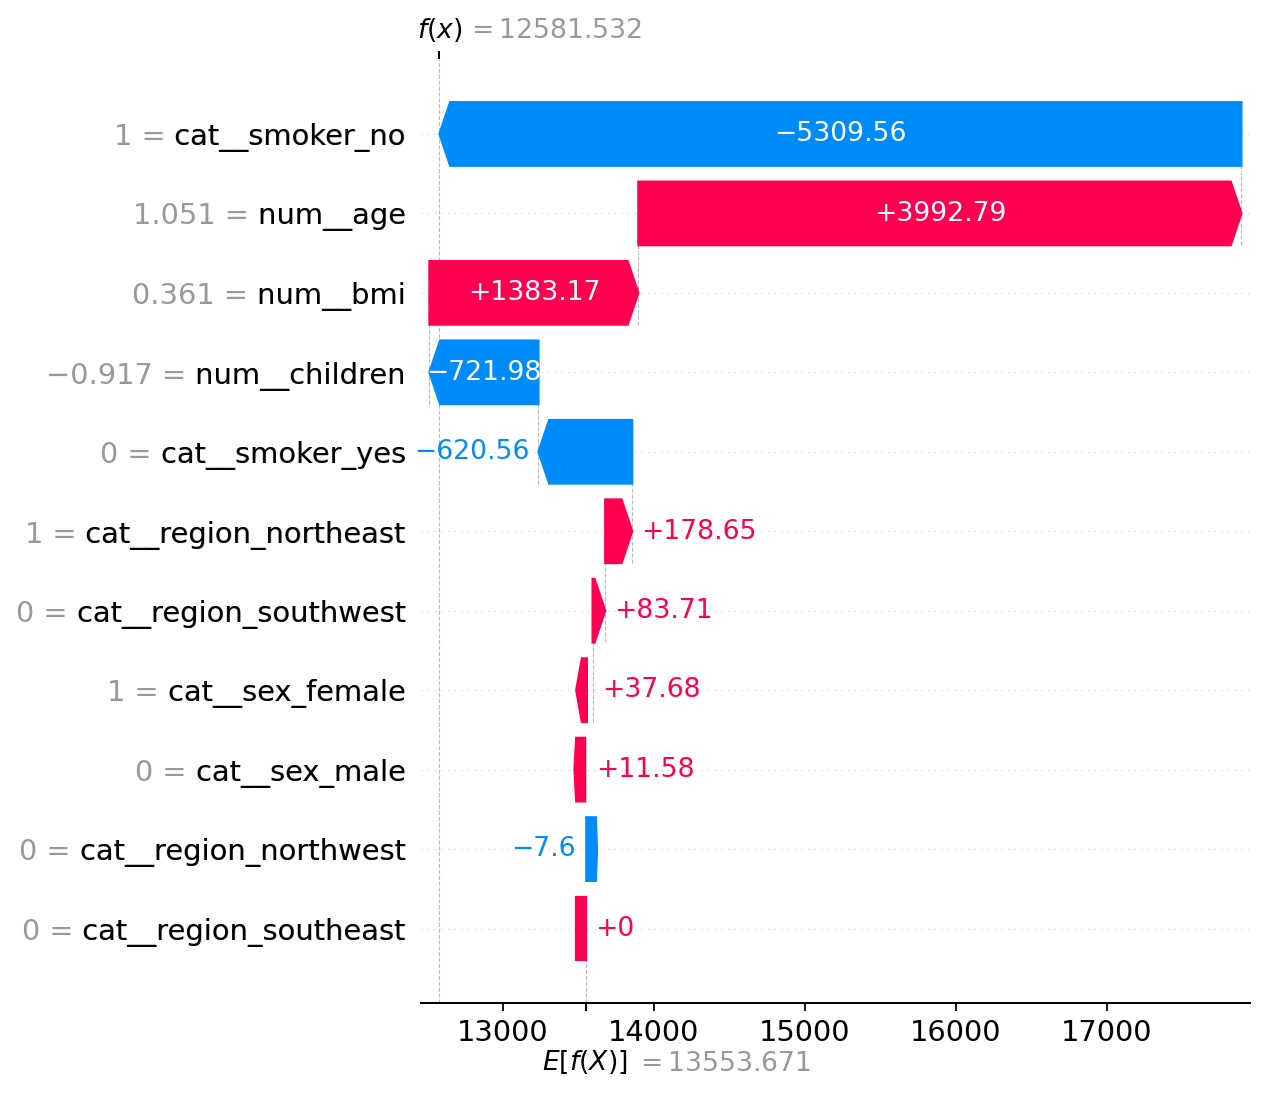

force -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_force_xgboost_regressor.png


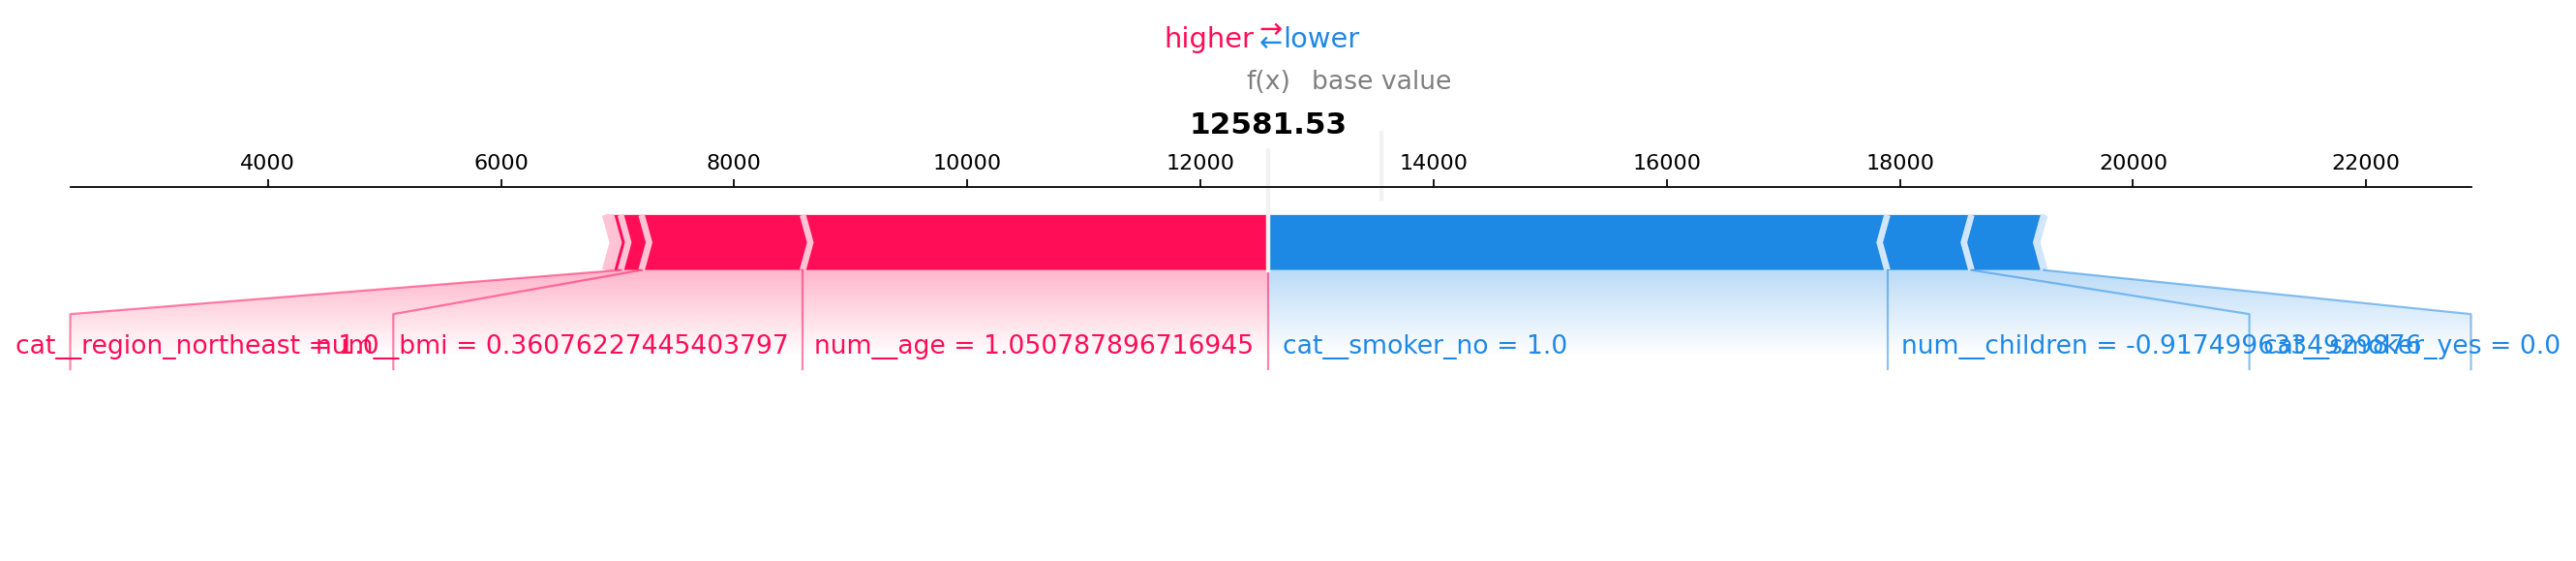

scatter -> ['c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_xgboost_regressor_cat_smoker_no.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_xgboost_regressor_num_age.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_xgboost_regressor_num_bmi.png']
top_features_json -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_top_features_xgboost_regressor.json
=== Linear Regression ===
summary -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_summary_linear_regression.png


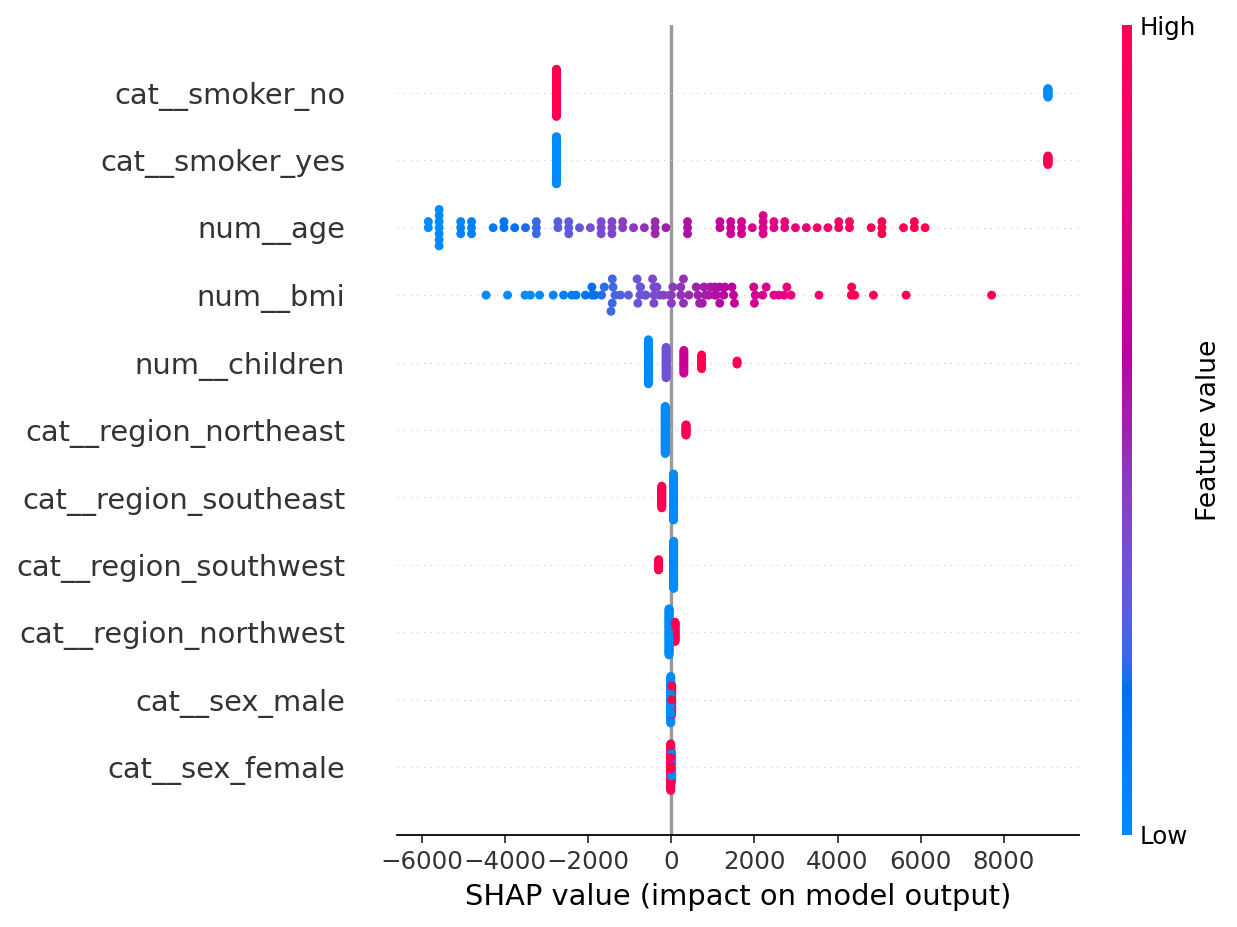

bar -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_bar_linear_regression.png


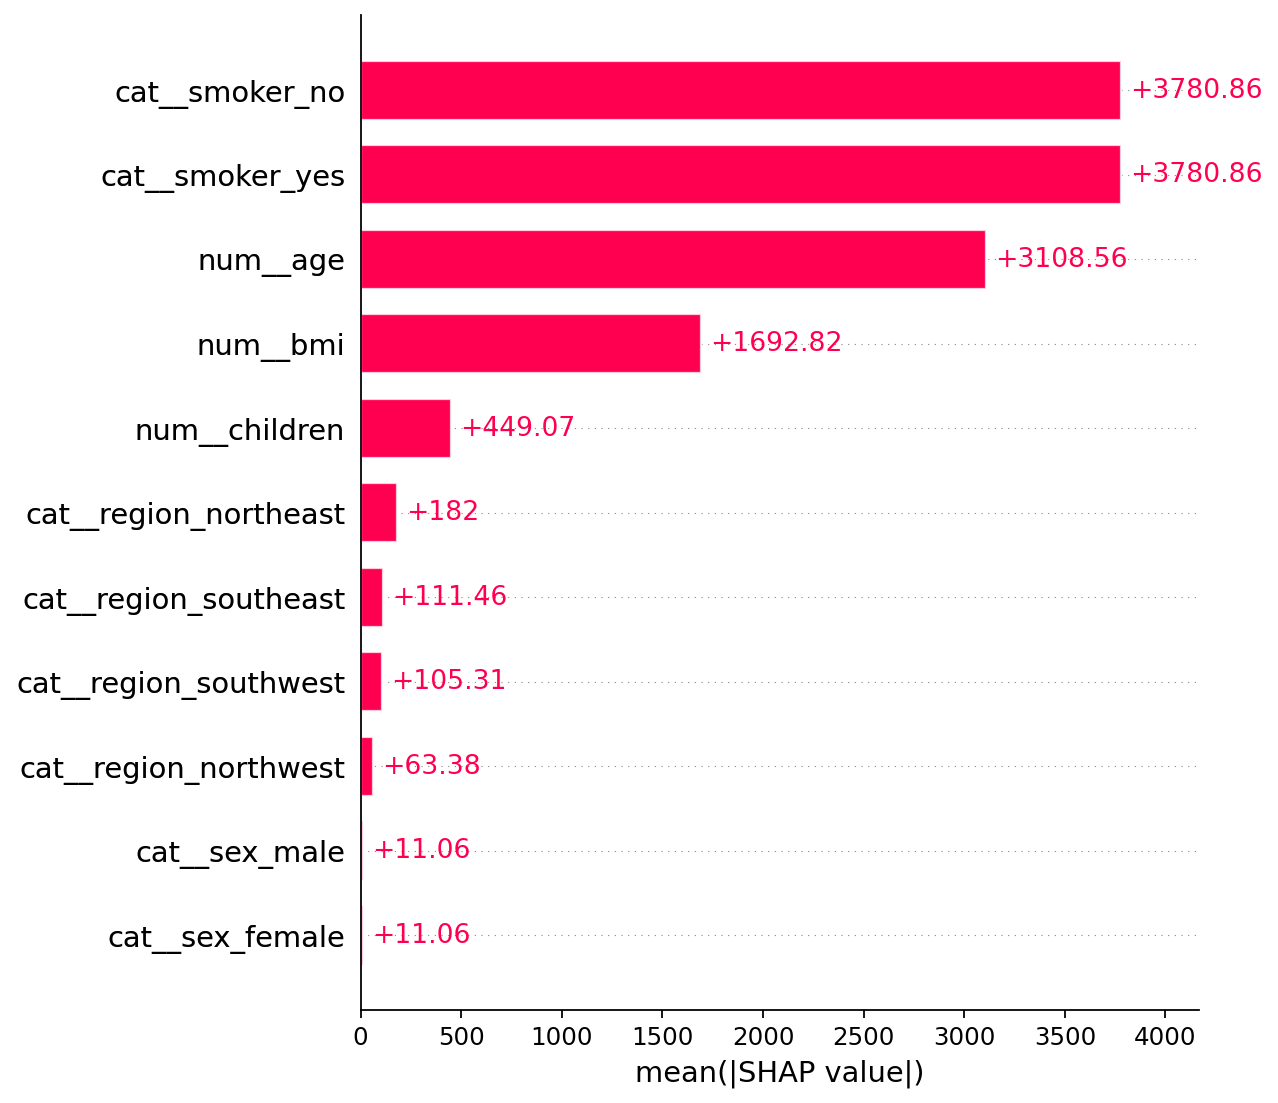

waterfall -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_waterfall_linear_regression.png


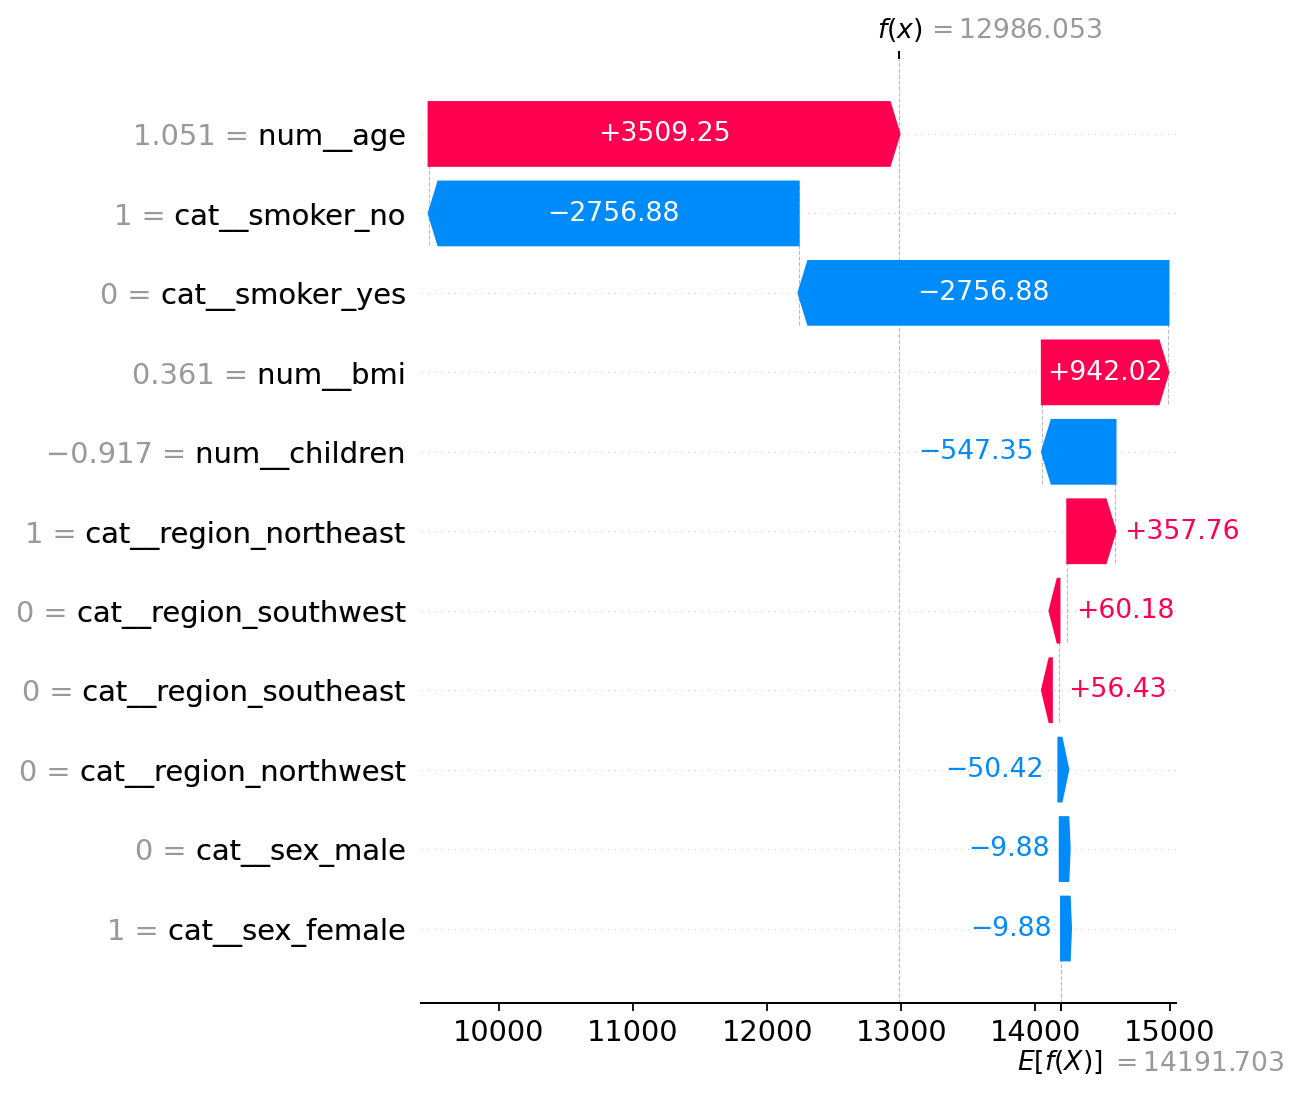

force -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_force_linear_regression.png


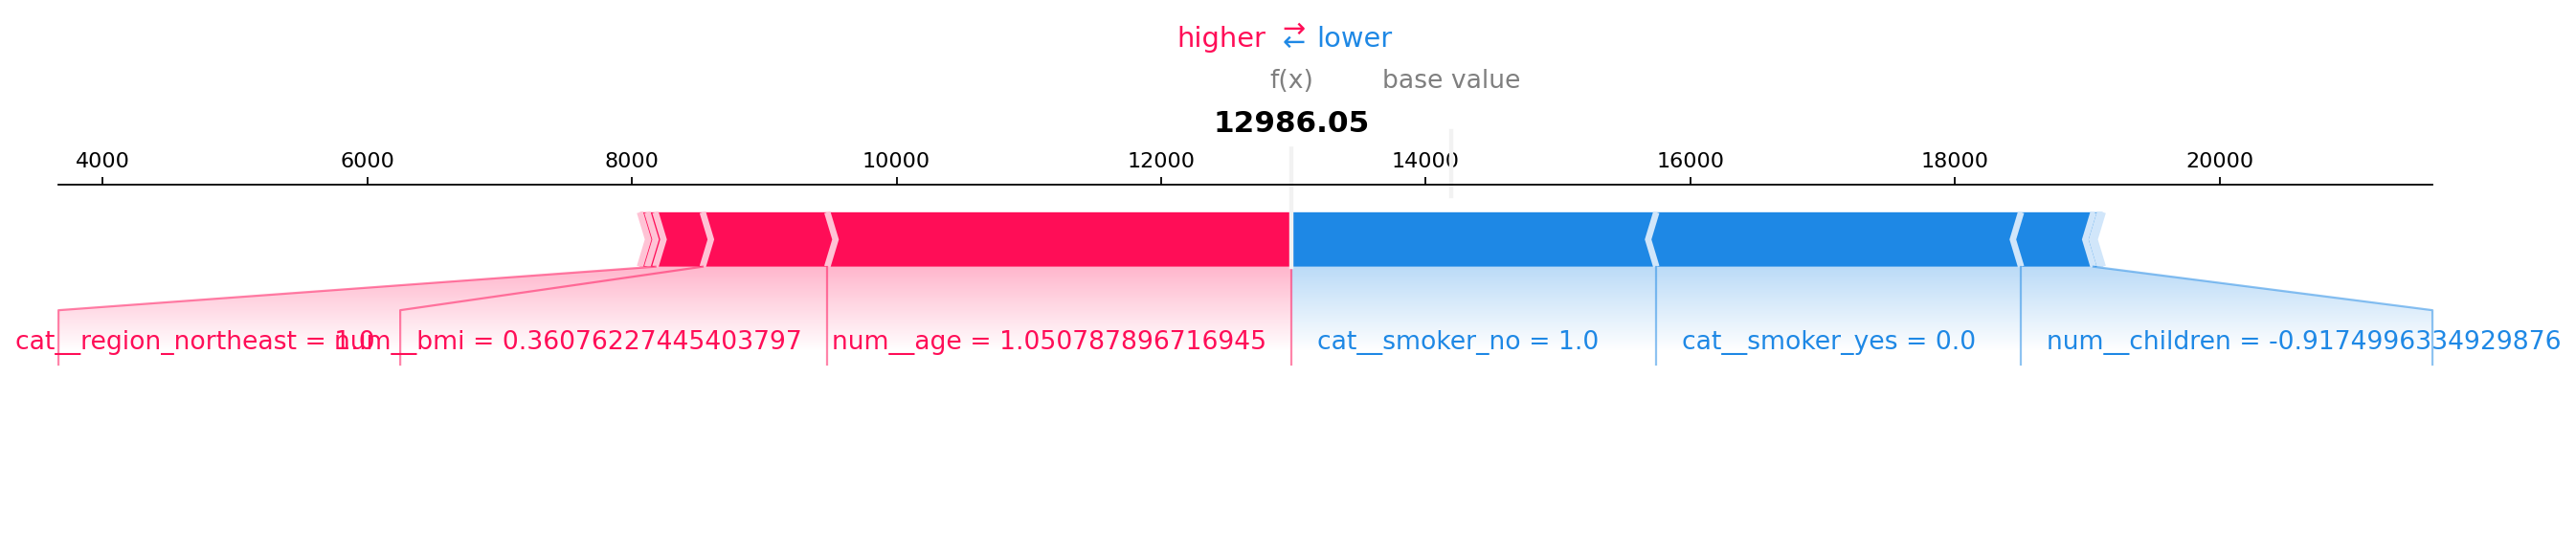

scatter -> ['c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_linear_regression_cat_smoker_no.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_linear_regression_cat_smoker_yes.png', 'c:\\Users\\Diana\\OneDrive\\Desktop\\ml_project_complete\\outputs\\regression\\figures\\shap\\shap_scatter_linear_regression_num_age.png']
top_features_json -> c:\Users\Diana\OneDrive\Desktop\ml_project_complete\outputs\regression\figures\shap\shap_top_features_linear_regression.json


<Figure size 1200x350 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

...

<Figure size 700x500 with 0 Axes>

<Figure size 1200x350 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

In [10]:

shap_dir = OUTPUT_ROOT / "regression" / "figures" / "shap"
shap_paths = save_shap_plots_all_models(
    "regression",
    tuned_models,
    X_train,
    X_test,
    shap_dir,
    sample_size=80,
)

for model_name, paths in shap_paths.items():
    print("===", model_name, "===")
    for plot_name, path in paths.items():
        if isinstance(path, str) and path.endswith(".png"):
            print(plot_name, "->", path)
            display(Image(filename=path))
        else:
            print(plot_name, "->", path)


### Interpretarea SHAP

SHAP explică influența fiecărei caracteristici asupra predicției. O valoare SHAP pozitivă împinge predicția în sus, iar o valoare SHAP negativă o împinge în jos.

În interpretarea globală, caracteristicile cu valoarea medie absolută SHAP cea mai mare sunt cele mai importante pentru model. În interpretarea locală, waterfall plot-ul arată pentru o observație concretă ce variabile au contribuit cel mai mult la rezultatul prezis.

Pentru concluzie, se vor menționa cele mai importante 3 caracteristici conform SHAP și se va explica sensul influenței lor asupra predicției.


## 8. Concluzie finală

Acest notebook a parcurs complet problema de regresie: definirea problemei, EDA, preprocesare, modele baseline, tuning pentru toți algoritmii, curbe de învățare și SHAP. Rezultatele salvate în folderul `outputs/regression` sunt folosite de aplicația Streamlit.

Modelul final poate fi ales în funcție de performanță, stabilitate și interpretabilitate. Pentru o prezentare riguroasă, nu este suficient să fie indicat doar cel mai bun scor; trebuie explicat și de ce modelul generalizează bine, ce variabile contează cel mai mult și care sunt limitele analizei.
